# 트레이별

In [16]:
import pandas as pd
import numpy as np
import traceback 

try:
    # --- 1. 파일 로드 ---
    print("파일 로드 중...")
    
    # 파일 로드 및 'Unnamed: 0' 컬럼 제거
    df_process = pd.read_csv('bat_process.csv', encoding='cp949')
    df_tat = pd.read_csv('bat_tat.csv', encoding='utf-8')
    
    if 'Unnamed: 0' in df_process.columns:
        df_process = df_process.drop(columns=['Unnamed: 0'])
        
    if 'Unnamed: 0' in df_tat.columns:
        df_tat = df_tat.drop(columns=['Unnamed: 0'])

    print("'df_process' (셀 데이터)와 'df_tat' (TAT 데이터) 로드 완료.")

    # --- 2. 'judge' 컬럼 0/1 인코딩 및 NaN/공백 처리 ---
    print(f"\n데이터 전처리 및 'judge' 0/1 인코딩 중...")
    
    # NaN/공백 처리 (read_csv에서 놓친 부분을 최종 정리)
    df_process.replace(r'^\s*$', np.nan, regex=True, inplace=True) 
    
    # '불량'일 때 1, 그 외('양품')일 때 0
    df_process['judge_encoded'] = (df_process['judge'] == '불량').astype(int)

    # --- 3. 집계(Aggregation) 정의 ---
    # [!!!] 모든 상세 공정 변수를 빠짐없이 추가 [!!!]
    metrics_to_agg = [
        # 1. 온도 변수
        'c1_temp_avg', 'dc1_temp_avg', 'c2_temp_avg', 'dc2_temp_avg',
        'c3_temp_avg', 'dc3_temp_avg', 'c4_temp_avg', 
        
        # 2. 용량/전류 변수 (Capa/Curr)
        'c1_capa', 'dc1_capa', 'c2_capa', 'dc2_capa', 'c3_capa', 'dc3_capa', 'c4_capa',
        'c1_curr_end', 'dc1_curr_end', 'c2_curr_end', 'dc2_curr_end',
        'c3_curr_end', 'dc3_curr_end', 'c4_curr_end', 
        'c1_ccval', 'c2_ccval', 'c3_ccval', 'c4_ccval', 'c3_cvval', 'c4_cvval',
        
        # 3. 전압 변수 (Voltage)
        'c1_voltage_avg', 'dc1_voltage_avg', 'c2_voltage_avg', 'dc2_voltage_avg',
        'c3_voltage_avg', 'dc3_voltage_avg', 'c4_voltage_avg', 
        
        # 4. 시간 변수 (Time)
        'c1_time_cc', 'c2_time_cc', 'c3_time_cc', 'c4_time_cc', 
        'c3_time_cv', 'c4_time_cv',
        
        # 5. Fitting/Imp/OCV/Meter 변수
        'dc1_capafit', 'dc2_capafit', 'dc3_capafit', 
        'pg1_impfit', 'pg1_imp', 'pc1_imp', 
        'pg1_voltage_start', 'pc1_voltage_start',
        'ocv1_ocv', 'ocv2_ocv', 'socv1_ocv', 'socv2_ocv', 'socv3_ocv',
        'ocv2_deltaocv', 'ocv1_deltaocv',
        
        # 6. M1 측정 변수 (두께, 저항 등)
        'm1_thick', 'm1_voltage', 'm1_res_ac', 'm1_mv', 'm1_voltage_an',
        
        # 7. 위치/Box/Cell No 변수 (숫자형만 포함. Box_col/row/dan 등은 범주형이므로 제외)
        'rta1_cell_no' 
    ]
    
    agg_dict = {}
    
    # 1. 불량률 계산을 위한 집계 (judge_encoded 사용)
    agg_dict['judge_encoded'] = ['mean', 'count', 'sum']
    
    # 2. 모든 공정 변수들 집계
    for col in metrics_to_agg:
        if col in df_process.columns:
            agg_dict[col] = ['mean', 'std']
        else:
            print(f"[경고] {col} 컬럼이 'df_process'에 없습니다. 집계에서 제외됩니다.")

    # --- 4. Tray 단위로 그룹화 및 집계 ---
    print("\n[4단계] Tray 단위로 데이터 집계 중 (Grouping by 'tray_id')...")
    df_tray_agg = df_process.groupby('tray_id').agg(agg_dict)
    print("  [4단계] 집계 완료.")

    
    # --- 5. 멀티레벨 컬럼명 정리 ---
    print("\n[5단계] 멀티레벨 컬럼명 정리 시작...")
    new_cols = []
    
    # ('c1_temp_avg', 'mean') -> 'c1_temp_avg_mean'
    for col_tuple in list(df_tray_agg.columns): 
        new_cols.append(f"{col_tuple[0]}_{col_tuple[1]}")
    
    df_tray_agg.columns = new_cols
    print("  [5단계] 컬럼명 정리 완료.")

    
    # --- 6. 컬럼명 변경 (더 알기 쉽게) ---
    print("\n[6단계] 'defect_rate' 컬럼명 변경 중...")
    
    # judge_encoded_mean이 없으면 KeyError가 나므로, 안전하게 처리
    if 'judge_encoded_mean' in df_tray_agg.columns:
        df_tray_agg = df_tray_agg.rename(columns={
            'judge_encoded_mean': 'defect_rate',   # [핵심] Y 변수 (트레이 불량률)
            'judge_encoded_count': 'cell_count',   # 트레이당 셀 개수
            'judge_encoded_sum': 'defect_count'    # 트레이당 불량 개수
        })
    
    # 표준편차(std) 계산 시 셀이 1개면 NaN이 됨 -> 0으로 채움
    std_cols = [col for col in df_tray_agg.columns if col.endswith('_std')]
    df_tray_agg[std_cols] = df_tray_agg[std_cols].fillna(0)
    print("  [6단계] 완료.")

    # --- 7. TAT 데이터와 병합 ---
    print(f"\n[7단계] 집계 데이터와 'df_tat' 병합 중...")
    # 'tray_id'와 'lot_id'를 기준으로 TAT 데이터와 병합
    final_tray_level_df = pd.merge(df_tray_agg, df_tat, on='tray_id', how='inner')
    print("  [7단계] 병합 완료.")

    # --- 8. 최종 파일 저장 ---
    output_file = 'final_tray_level_dataset.csv'
    final_tray_level_df.to_csv(output_file, index=False)
    
    print("\n" + "="*50)
    print("      [완료] 트레이별 집계 데이터 생성 완료")
    print("="*50)
    print(f"\n  >> '{output_file}' 파일이 저장되었습니다.")


except FileNotFoundError as e:
    print(f"[오류] 파일을 찾을 수 없습니다: {e}. (bat_process.csv, bat_tat.csv 파일이 필요합니다)")
except Exception as e:
    print(f"--- [오류 발생] ---")
    print(f"오류 메시지: {e}")
    print("\n--- [Traceback (오류 위치)] ---")
    traceback.print_exc()
    print("-------------------------")

파일 로드 중...
'df_process' (셀 데이터)와 'df_tat' (TAT 데이터) 로드 완료.

데이터 전처리 및 'judge' 0/1 인코딩 중...

[4단계] Tray 단위로 데이터 집계 중 (Grouping by 'tray_id')...
  [4단계] 집계 완료.

[5단계] 멀티레벨 컬럼명 정리 시작...
  [5단계] 컬럼명 정리 완료.

[6단계] 'defect_rate' 컬럼명 변경 중...
  [6단계] 완료.

[7단계] 집계 데이터와 'df_tat' 병합 중...
  [7단계] 병합 완료.

      [완료] 트레이별 집계 데이터 생성 완료

  >> 'final_tray_level_dataset.csv' 파일이 저장되었습니다.


# 셀 별

In [17]:
import pandas as pd
import numpy as np
import traceback 

try:
    # --- 1. 파일 로드 ---
    print("🔋 파일 로드 중...")
    
    # 파일 로드 및 'Unnamed: 0' 컬럼 제거
    df_process = pd.read_csv('bat_process.csv', encoding='cp949')
    df_tat = pd.read_csv('bat_tat.csv', encoding='utf-8')
    
    if 'Unnamed: 0' in df_process.columns:
        df_process = df_process.drop(columns=['Unnamed: 0'])
        
    if 'Unnamed: 0' in df_tat.columns:
        df_tat = df_tat.drop(columns=['Unnamed: 0'])

    print("'df_process' (셀 데이터)와 'df_tat' (TAT 데이터) 로드 완료.")

    # --- 2. 'judge' 컬럼 0/1 인코딩 및 NaN/공백 처리 ---
    print(f"\n✨ 데이터 전처리 및 'judge' 0/1 인코딩 중...")
    
    # NaN/공백 처리 (read_csv에서 놓친 부분을 최종 정리)
    df_process.replace(r'^\s*$', np.nan, regex=True, inplace=True) 
    
    # '불량'일 때 1, 그 외('양품')일 때 0
    # [핵심] Y 변수 (개별 셀의 불량 여부)
    df_process['judge_encoded'] = (df_process['judge'] == '불량').astype(int)
    print("  'judge_encoded' (Y 변수) 생성 완료.")

    # --- 3. 모델링에 사용할 컬럼 정의 (공정 변수 + Y 변수) ---
    # [!!!] 모든 상세 공정 변수를 빠짐없이 추가 [!!!]
    metrics_to_keep = [
        # 1. 온도 변수
        'c1_temp_avg', 'dc1_temp_avg', 'c2_temp_avg', 'dc2_temp_avg',
        'c3_temp_avg', 'dc3_temp_avg', 'c4_temp_avg', 
        
        # 2. 용량/전류 변수 (Capa/Curr)
        'c1_capa', 'dc1_capa', 'c2_capa', 'dc2_capa', 'c3_capa', 'dc3_capa', 'c4_capa',
        'c1_curr_end', 'dc1_curr_end', 'c2_curr_end', 'dc2_curr_end',
        'c3_curr_end', 'dc3_curr_end', 'c4_curr_end', 
        'c1_ccval', 'c2_ccval', 'c3_ccval', 'c4_ccval', 'c3_cvval', 'c4_cvval',
        
        # 3. 전압 변수 (Voltage)
        'c1_voltage_avg', 'dc1_voltage_avg', 'c2_voltage_avg', 'dc2_voltage_avg',
        'c3_voltage_avg', 'dc3_voltage_avg', 'c4_voltage_avg', 
        
        # 4. 시간 변수 (Time)
        'c1_time_cc', 'c2_time_cc', 'c3_time_cc', 'c4_time_cc', 
        'c3_time_cv', 'c4_time_cv',
        
        # 5. Fitting/Imp/OCV/Meter 변수
        'dc1_capafit', 'dc2_capafit', 'dc3_capafit', 
        'pg1_impfit', 'pg1_imp', 'pc1_imp', 
        'pg1_voltage_start', 'pc1_voltage_start',
        'ocv1_ocv', 'ocv2_ocv', 'socv1_ocv', 'socv2_ocv', 'socv3_ocv',
        'ocv2_deltaocv', 'ocv1_deltaocv',
        
        # 6. M1 측정 변수 (두께, 저항 등)
        'm1_thick', 'm1_voltage', 'm1_res_ac', 'm1_mv', 'm1_voltage_an',
        
        # 7. 위치/Box/Cell No 변수 (숫자형만 포함)
        'rta1_cell_no' 
    ]
    
    # 공정 데이터 (X 변수)와 목표 변수 (Y 변수)만 추출
    cols_to_select = ['tray_id', 'lot_id', 'judge_encoded'] + [col for col in metrics_to_keep if col in df_process.columns]
    df_cell_data = df_process[cols_to_select].copy()
    
    # TAT 데이터에서 필요한 컬럼만 추출 (TAT 변수들은 트레이/랏 단위)
    # TAT 변수가 X 변수로 활용됩니다.
    tat_cols = [col for col in df_tat.columns if col not in ['tray_id', 'lot_id']]
    df_tat_vars = df_tat[['tray_id'] + tat_cols].copy() 

    # --- 4. TAT 데이터와 병합 (셀 수준으로 확장) ---
    # 각 셀 데이터('df_cell_data')에 해당 셀이 속한 트레이의 TAT 정보를 병합
    print(f"\n🔗 [4단계] 셀 데이터와 'df_tat' 병합 중 (셀 단위로 TAT 변수 확장)...")
    final_cell_level_df = pd.merge(df_cell_data, df_tat_vars, on='tray_id', how='left')
    
    # 'lot_id'는 분석에 사용될 수 있으므로 남겨둡니다.
    print("  [4단계] 병합 완료.")

    # --- 5. 최종 데이터셋 정리 및 저장 ---
    # 최종 데이터프레임의 결측치 확인 및 처리 (모델링 전 단계로 남겨둠)
    
    output_file = 'final_cell_level_dataset.csv'
    final_cell_level_df.to_csv(output_file, index=False)
    
    print("\n" + "="*50)
    print("      [완료] 개별 **셀 단위** 모델링 데이터 생성 완료")
    print("="*50)
    print(f"  **총 데이터 크기:** {final_cell_level_df.shape}")
    print(f"  **주요 X 변수 예시:** {list(final_cell_level_df.columns[3:7])} ...")
    print(f"  **Y 변수:** judge_encoded (0:양품, 1:불량)")
    print(f"\n  >> '{output_file}' 파일이 저장되었습니다.")


except FileNotFoundError as e:
    print(f"[오류] 파일을 찾을 수 없습니다: {e}. (bat_process.csv, bat_tat.csv 파일이 필요합니다)")
except Exception as e:
    print(f"--- [오류 발생] ---")
    print(f"오류 메시지: {e}")
    print("\n--- [Traceback (오류 위치)] ---")
    traceback.print_exc()
    print("-------------------------")

🔋 파일 로드 중...
'df_process' (셀 데이터)와 'df_tat' (TAT 데이터) 로드 완료.

✨ 데이터 전처리 및 'judge' 0/1 인코딩 중...
  'judge_encoded' (Y 변수) 생성 완료.

🔗 [4단계] 셀 데이터와 'df_tat' 병합 중 (셀 단위로 TAT 변수 확장)...
  [4단계] 병합 완료.

      [완료] 개별 **셀 단위** 모델링 데이터 생성 완료
  **총 데이터 크기:** (39019, 84)
  **주요 X 변수 예시:** ['c1_temp_avg', 'dc1_temp_avg', 'c2_temp_avg', 'dc2_temp_avg'] ...
  **Y 변수:** judge_encoded (0:양품, 1:불량)

  >> 'final_cell_level_dataset.csv' 파일이 저장되었습니다.


# 모델선정

## 모델 선택

--- [시뮬레이션 설정] 공정별 최적 온도 (범위의 중간값) ---
  ✅ c1_temp_avg: 284.00°C
  ✅ dc1_temp_avg: 283.50°C
  ✅ c2_temp_avg: 285.50°C
  ✅ dc2_temp_avg: 283.00°C
  ✅ c3_temp_avg: 280.25°C
  ✅ dc3_temp_avg: 280.25°C
  ✅ c4_temp_avg: 280.25°C
-------------------------------------------------
--- [시뮬레이션 설정] 공정별 변수 자동 구성 ---
  ✅ C1 모델: 5개 변수 사용 (제어 변수: c1_temp_avg)
  ✅ DC1 모델: 3개 변수 사용 (제어 변수: dc1_temp_avg)
  ✅ C2 모델: 5개 변수 사용 (제어 변수: c2_temp_avg)
  ✅ DC2 모델: 3개 변수 사용 (제어 변수: dc2_temp_avg)
  ✅ C3 모델: 7개 변수 사용 (제어 변수: c3_temp_avg)
  ✅ DC3 모델: 3개 변수 사용 (제어 변수: dc3_temp_avg)
  ✅ C4 모델: 7개 변수 사용 (제어 변수: c4_temp_avg)
-------------------------------------------------
데이터 로드 완료. (원본 39019개 행 -> NaN 제거 후 39019개 행 사용)
전체 데이터 실제 불량률: 3.13 %

      [ C1 공정 ] 1단계: 모델 성능 비교
[C1] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[C1] 모델 평가 완료.

✅ [C1] 성능 비교 그래프 저장: C1_performance.png


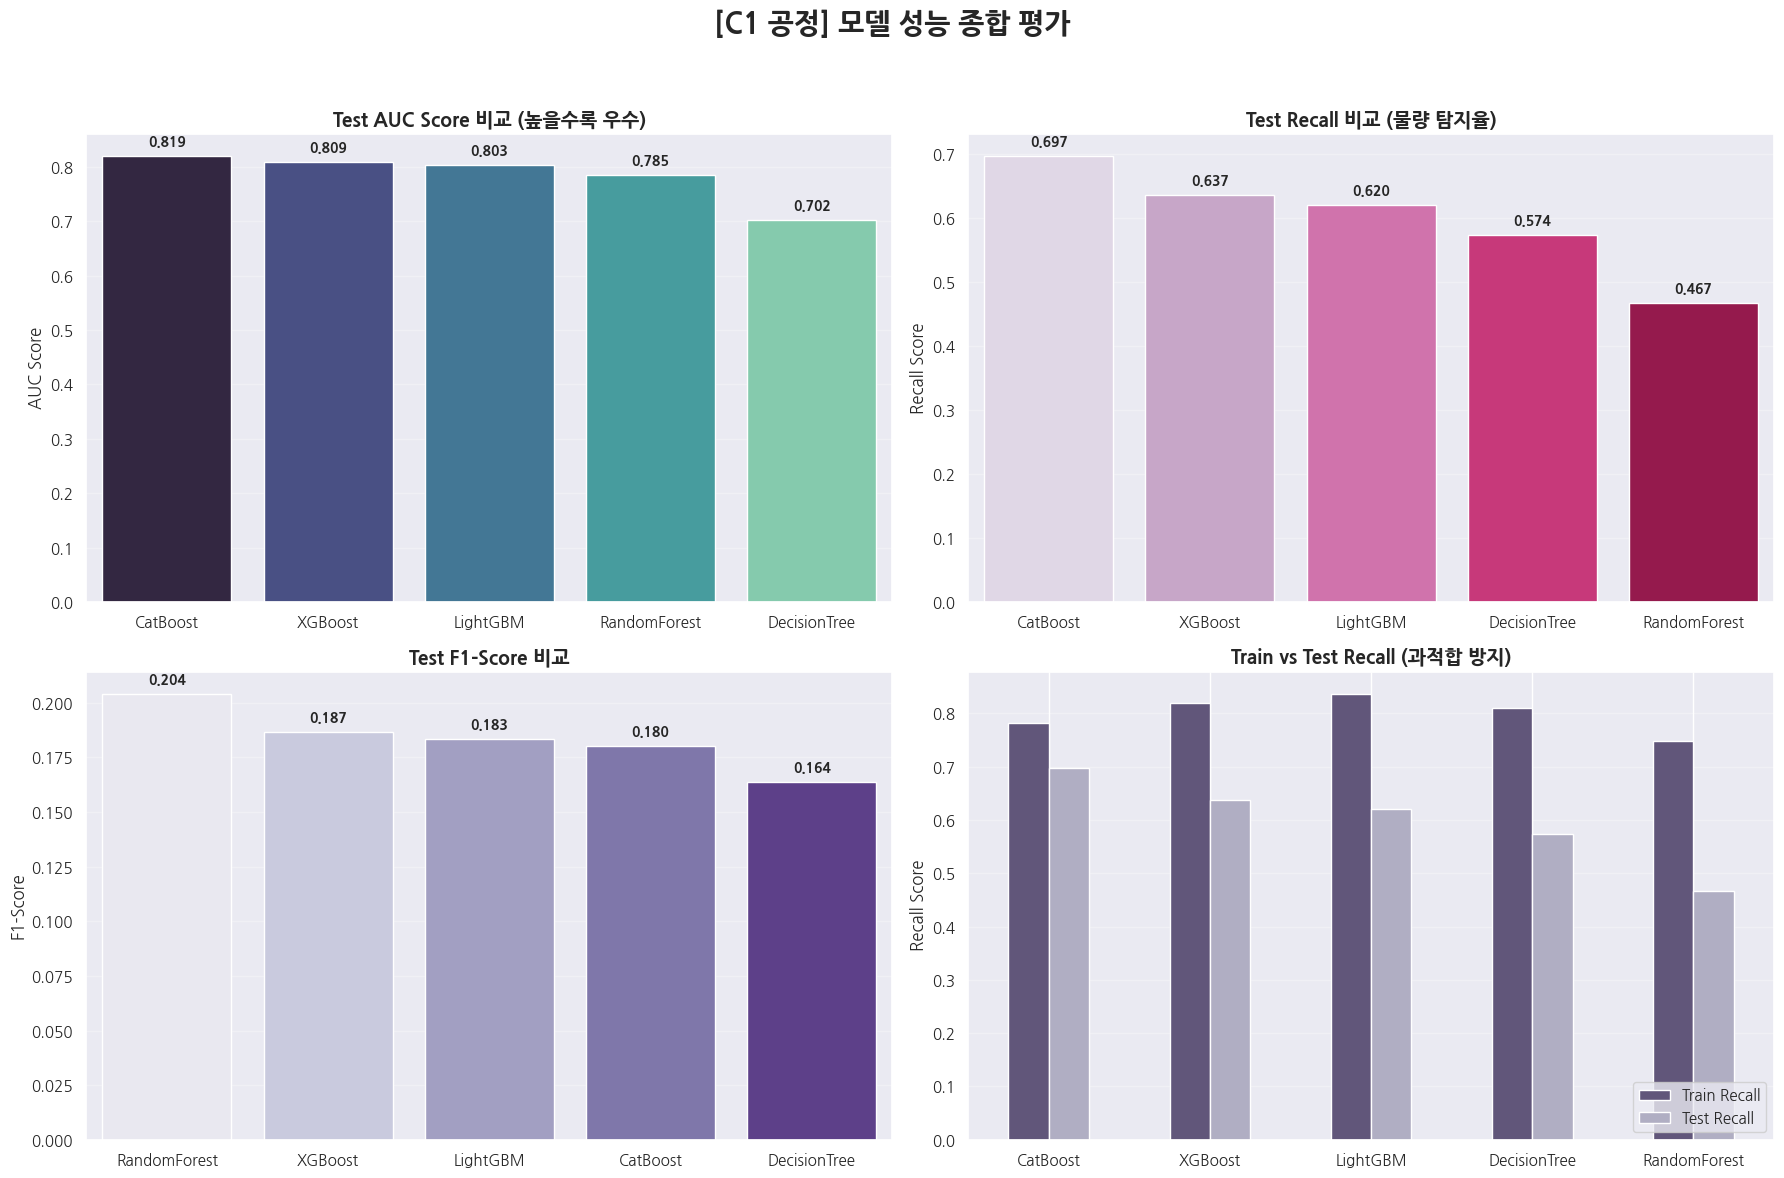


      [ C1 공정 ] 2단계: 최적 모델 시뮬레이션
[C1] 최적 모델로 'CatBoost' 선정 (Test Recall: 0.697)
[C1] 시뮬레이션 실행 중... (제어 변수: c1_temp_avg -> 284.00°C)

--- C1 'CatBoost' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2464 개 (21.0490 %)
  개선 후 예상 불량 셀 수: 2 개 (0.0171 %)
  🔥 감소 효과: 2462 개 (불량률 21.0319 %p 감소)

      [ DC1 공정 ] 1단계: 모델 성능 비교
[DC1] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[DC1] 모델 평가 완료.

✅ [DC1] 성능 비교 그래프 저장: DC1_performance.png


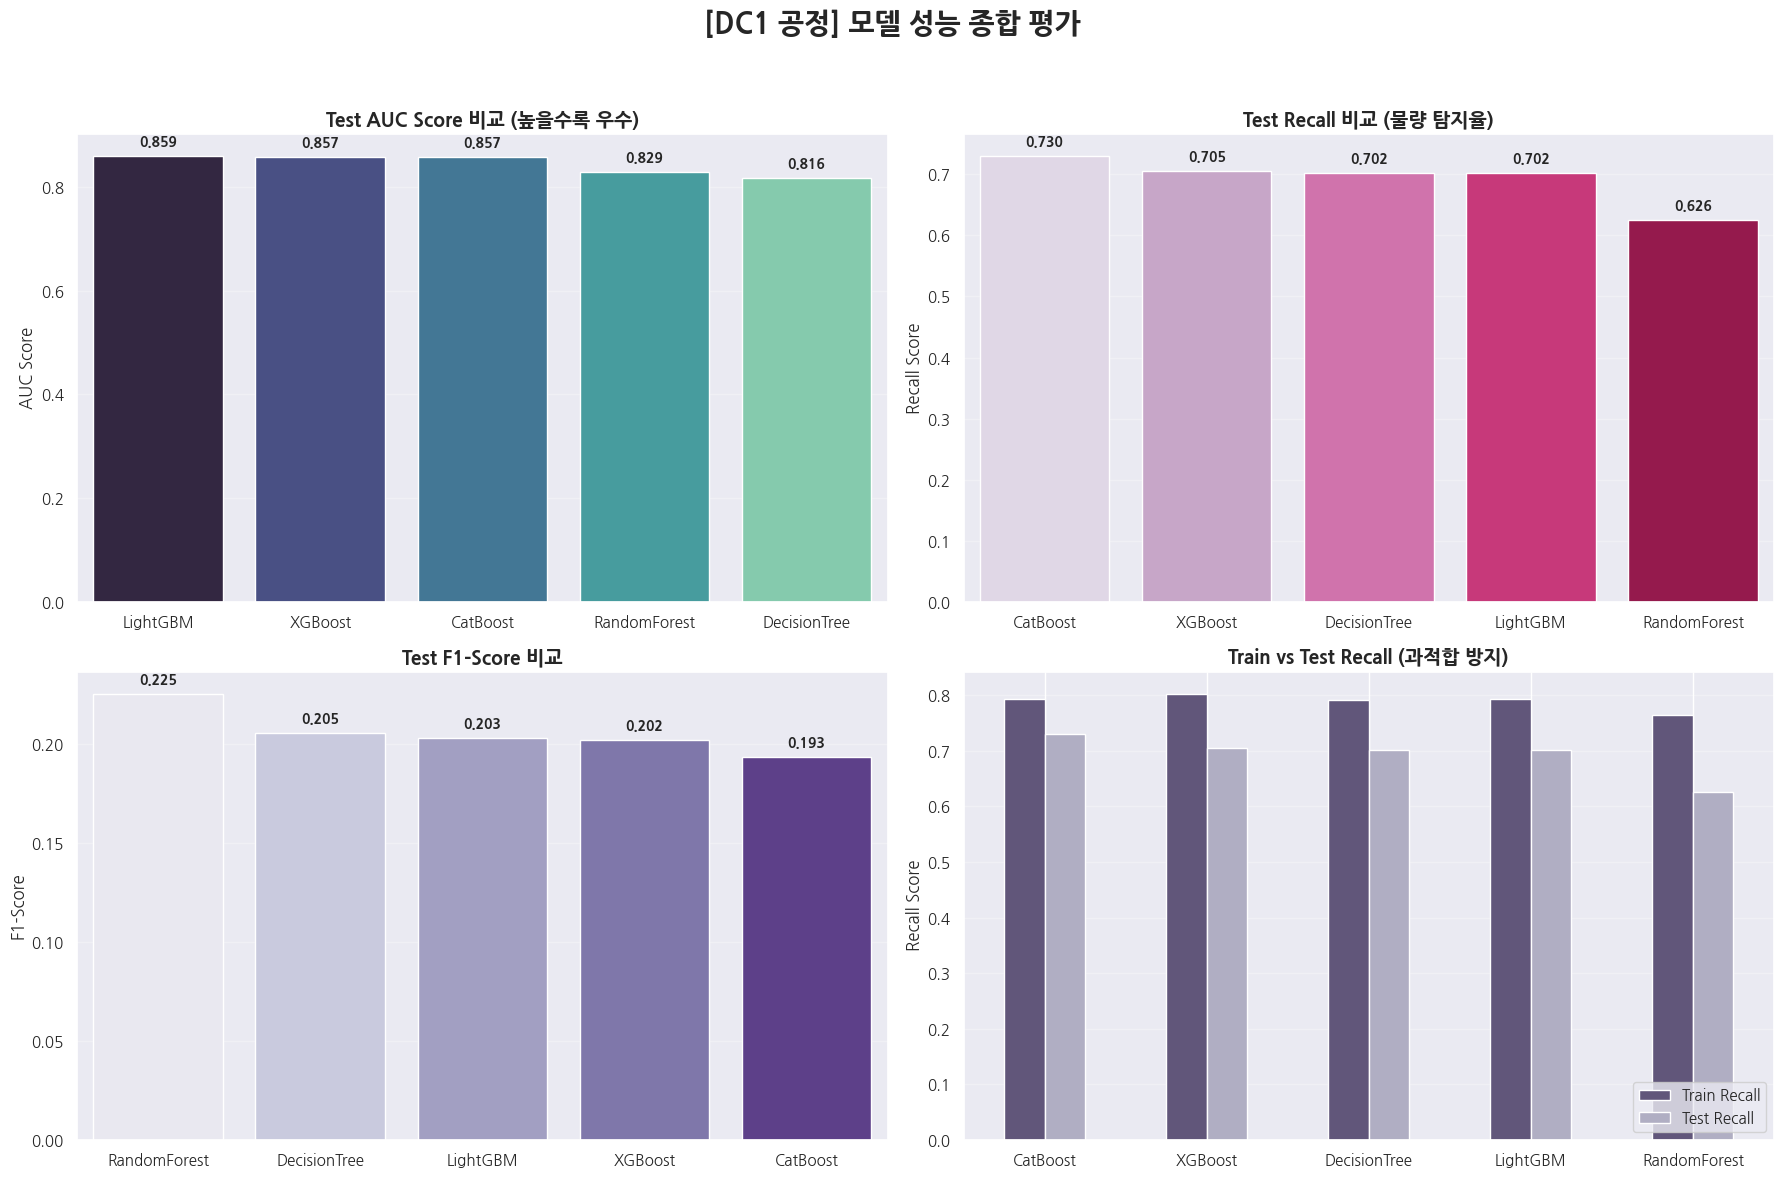


      [ DC1 공정 ] 2단계: 최적 모델 시뮬레이션
[DC1] 최적 모델로 'CatBoost' 선정 (Test Recall: 0.730)
[DC1] 시뮬레이션 실행 중... (제어 변수: dc1_temp_avg -> 283.50°C)

--- DC1 'CatBoost' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2397 개 (20.4767 %)
  개선 후 예상 불량 셀 수: 404 개 (3.4512 %)
  🔥 감소 효과: 1993 개 (불량률 17.0255 %p 감소)

      [ C2 공정 ] 1단계: 모델 성능 비교
[C2] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[C2] 모델 평가 완료.

✅ [C2] 성능 비교 그래프 저장: C2_performance.png


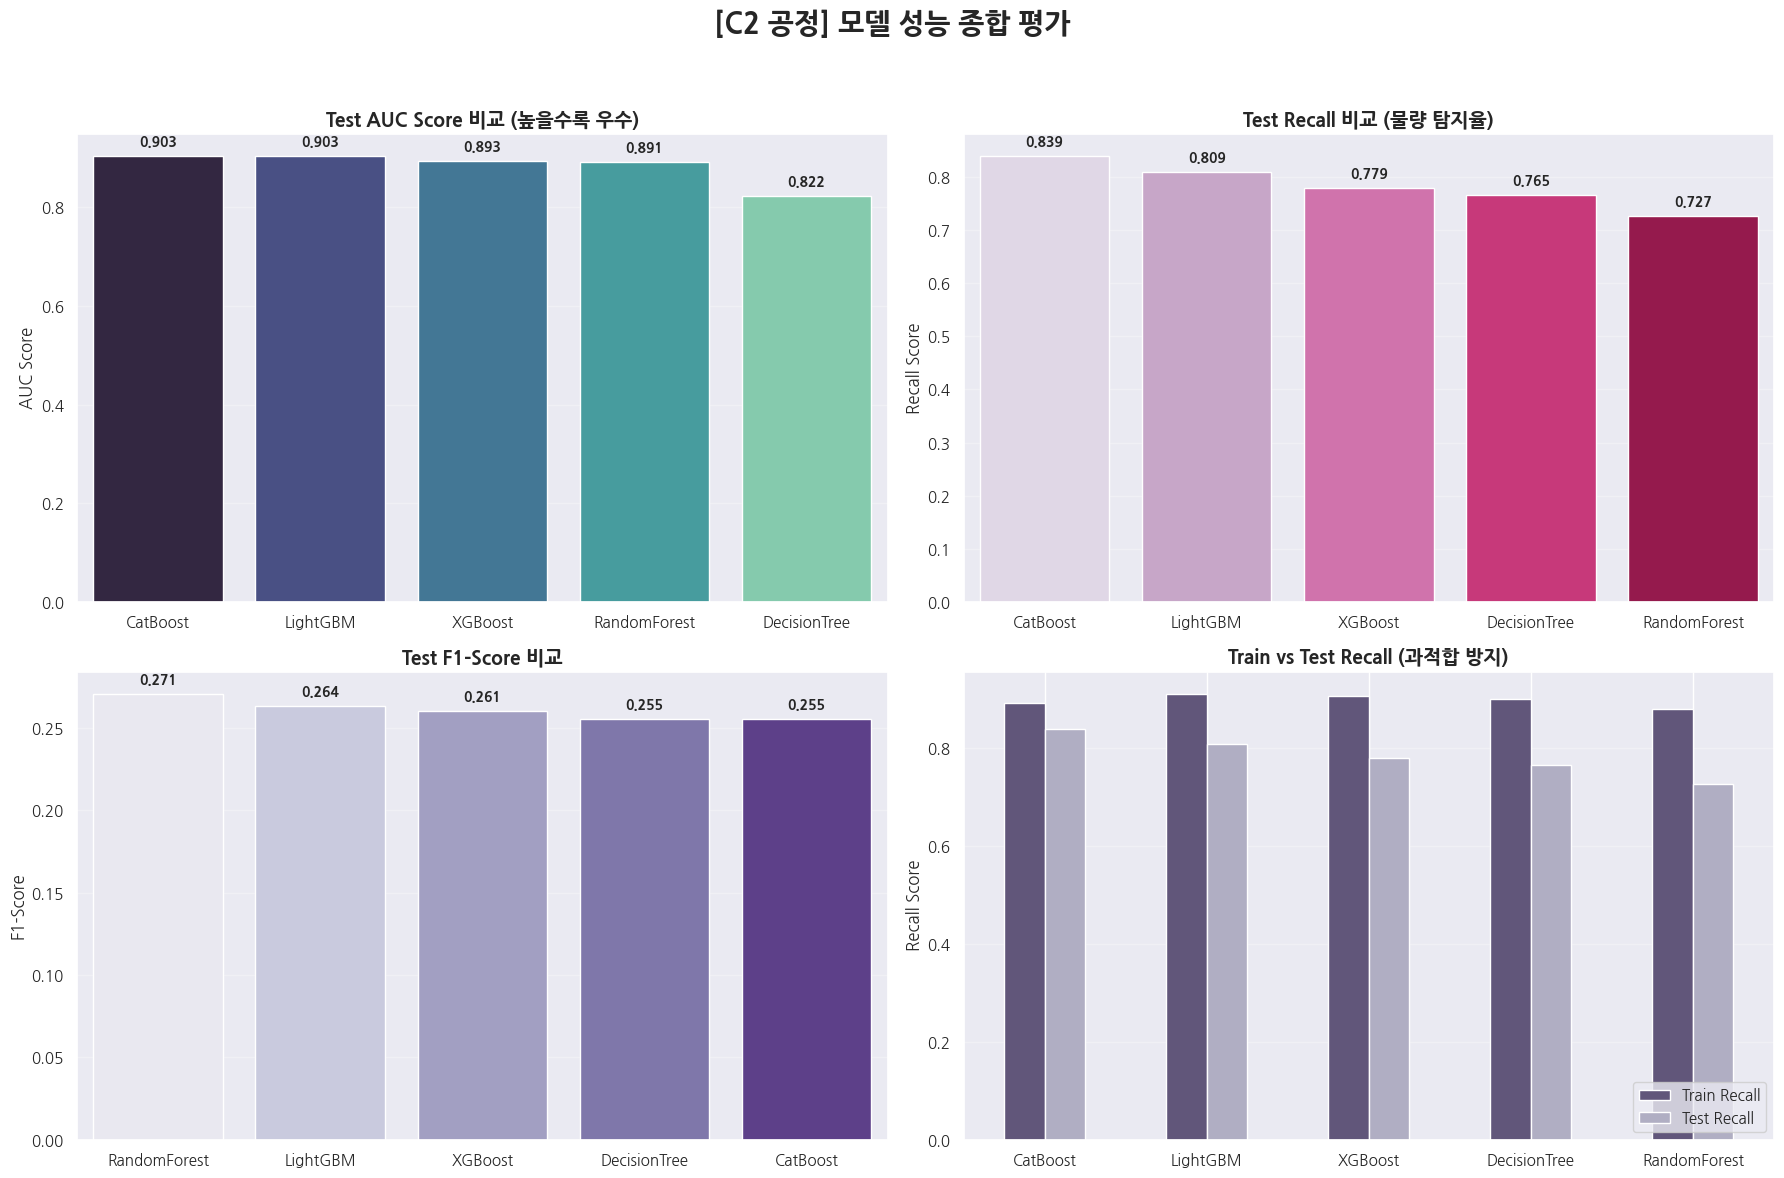


      [ C2 공정 ] 2단계: 최적 모델 시뮬레이션
[C2] 최적 모델로 'CatBoost' 선정 (Test Recall: 0.839)
[C2] 시뮬레이션 실행 중... (제어 변수: c2_temp_avg -> 285.50°C)

--- C2 'CatBoost' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2039 개 (17.4184 %)
  개선 후 예상 불량 셀 수: 337 개 (2.8789 %)
  🔥 감소 효과: 1702 개 (불량률 14.5396 %p 감소)

      [ DC2 공정 ] 1단계: 모델 성능 비교
[DC2] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[DC2] 모델 평가 완료.

✅ [DC2] 성능 비교 그래프 저장: DC2_performance.png


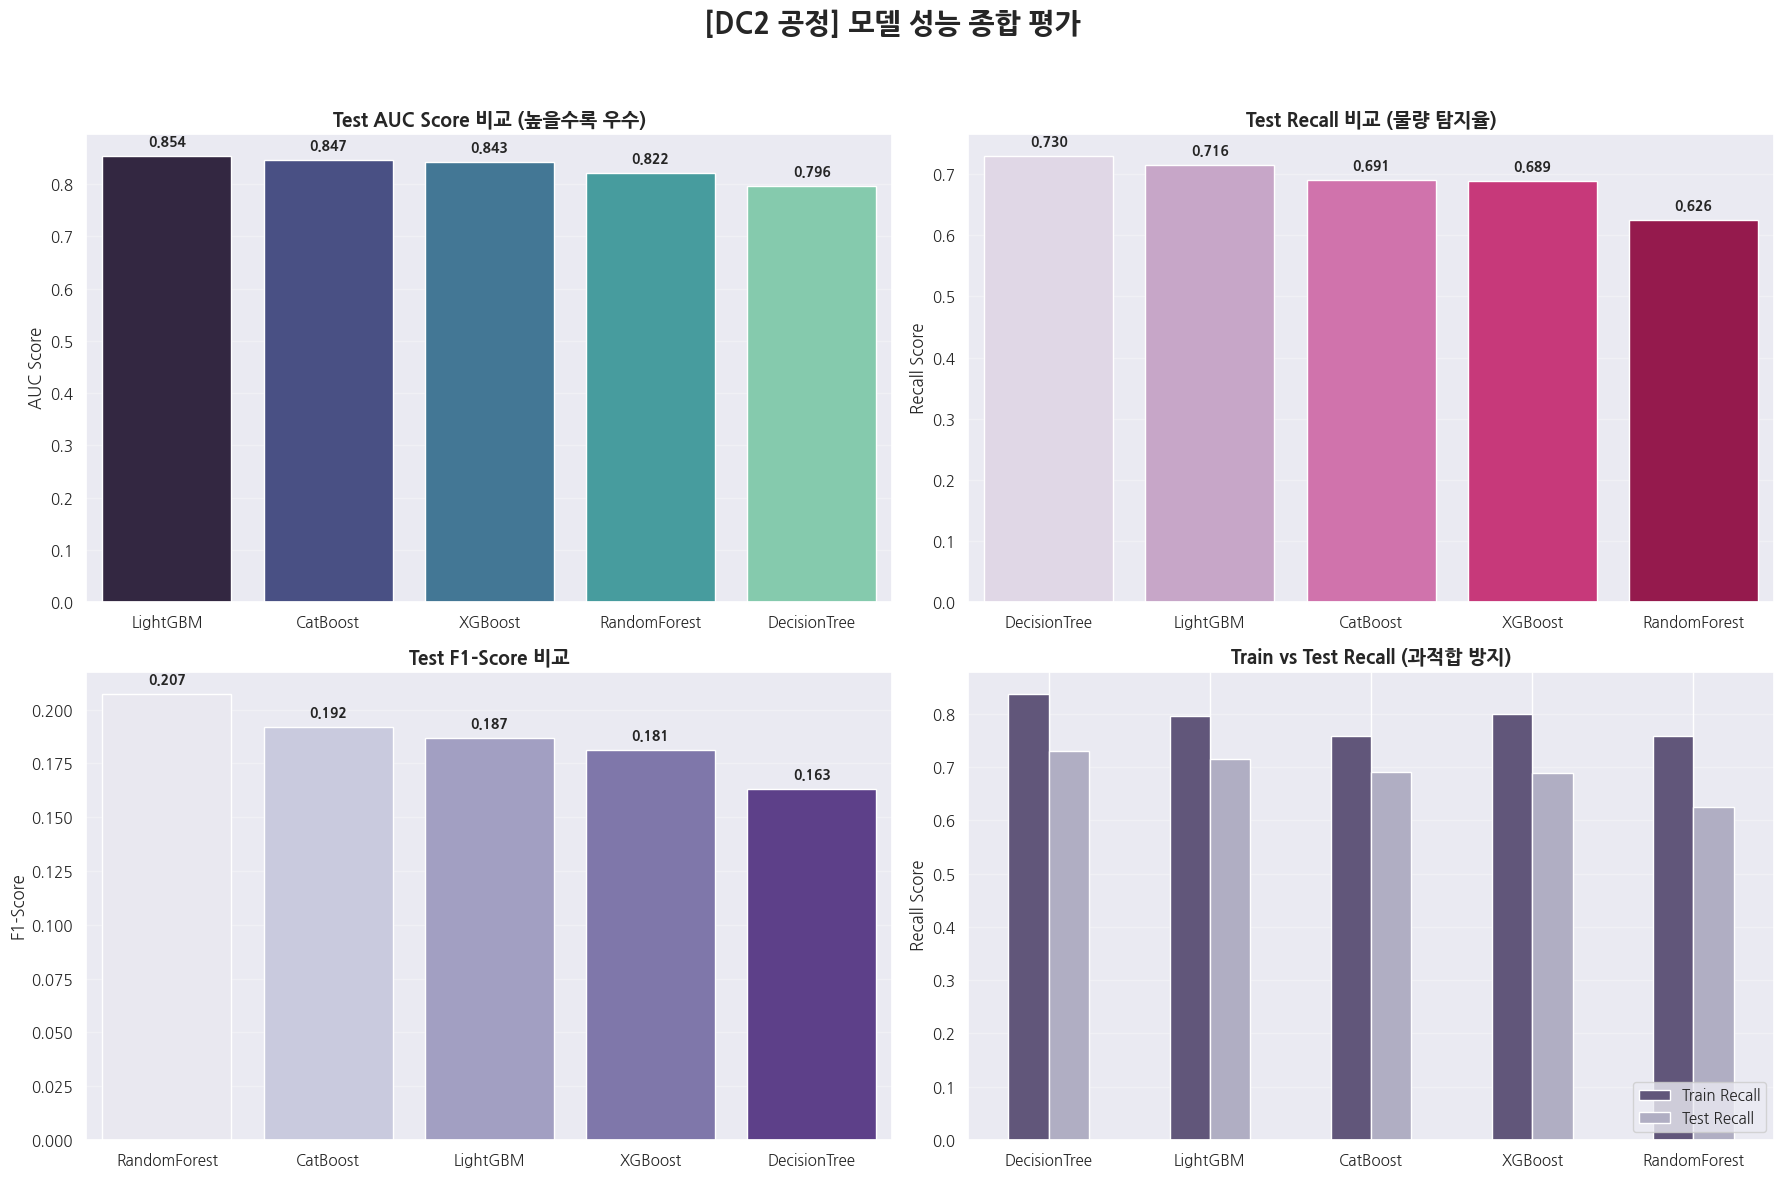


      [ DC2 공정 ] 2단계: 최적 모델 시뮬레이션
[DC2] 최적 모델로 'DecisionTree' 선정 (Test Recall: 0.730)
[DC2] 시뮬레이션 실행 중... (제어 변수: dc2_temp_avg -> 283.00°C)

--- DC2 'DecisionTree' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2912 개 (24.8761 %)
  개선 후 예상 불량 셀 수: 2165 개 (18.4948 %)
  🔥 감소 효과: 747 개 (불량률 6.3813 %p 감소)

      [ C3 공정 ] 1단계: 모델 성능 비교
[C3] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[C3] 모델 평가 완료.

✅ [C3] 성능 비교 그래프 저장: C3_performance.png


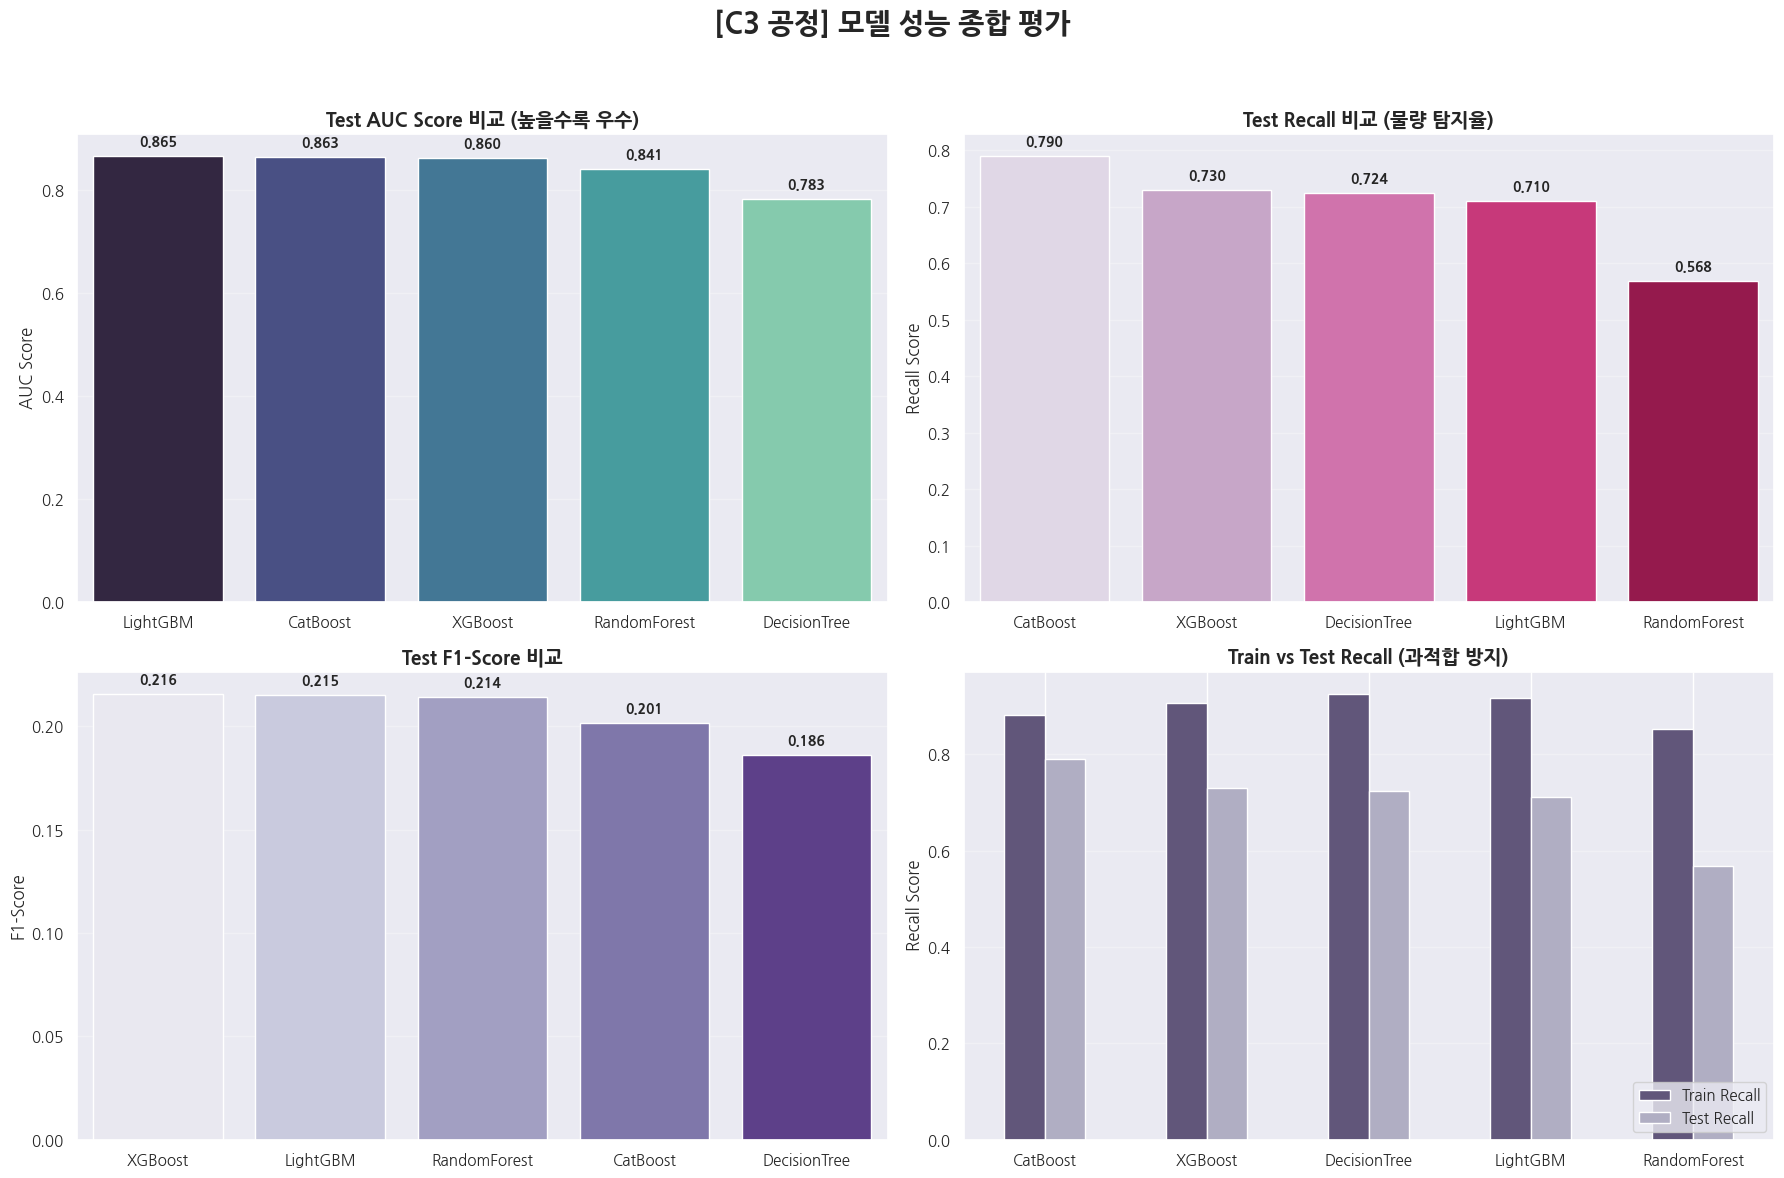


      [ C3 공정 ] 2단계: 최적 모델 시뮬레이션
[C3] 최적 모델로 'CatBoost' 선정 (Test Recall: 0.790)
[C3] 시뮬레이션 실행 중... (제어 변수: c3_temp_avg -> 280.25°C)

--- C3 'CatBoost' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2503 개 (21.3822 %)
  개선 후 예상 불량 셀 수: 669 개 (5.7150 %)
  🔥 감소 효과: 1834 개 (불량률 15.6672 %p 감소)

      [ DC3 공정 ] 1단계: 모델 성능 비교
[DC3] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[DC3] 모델 평가 완료.

✅ [DC3] 성능 비교 그래프 저장: DC3_performance.png


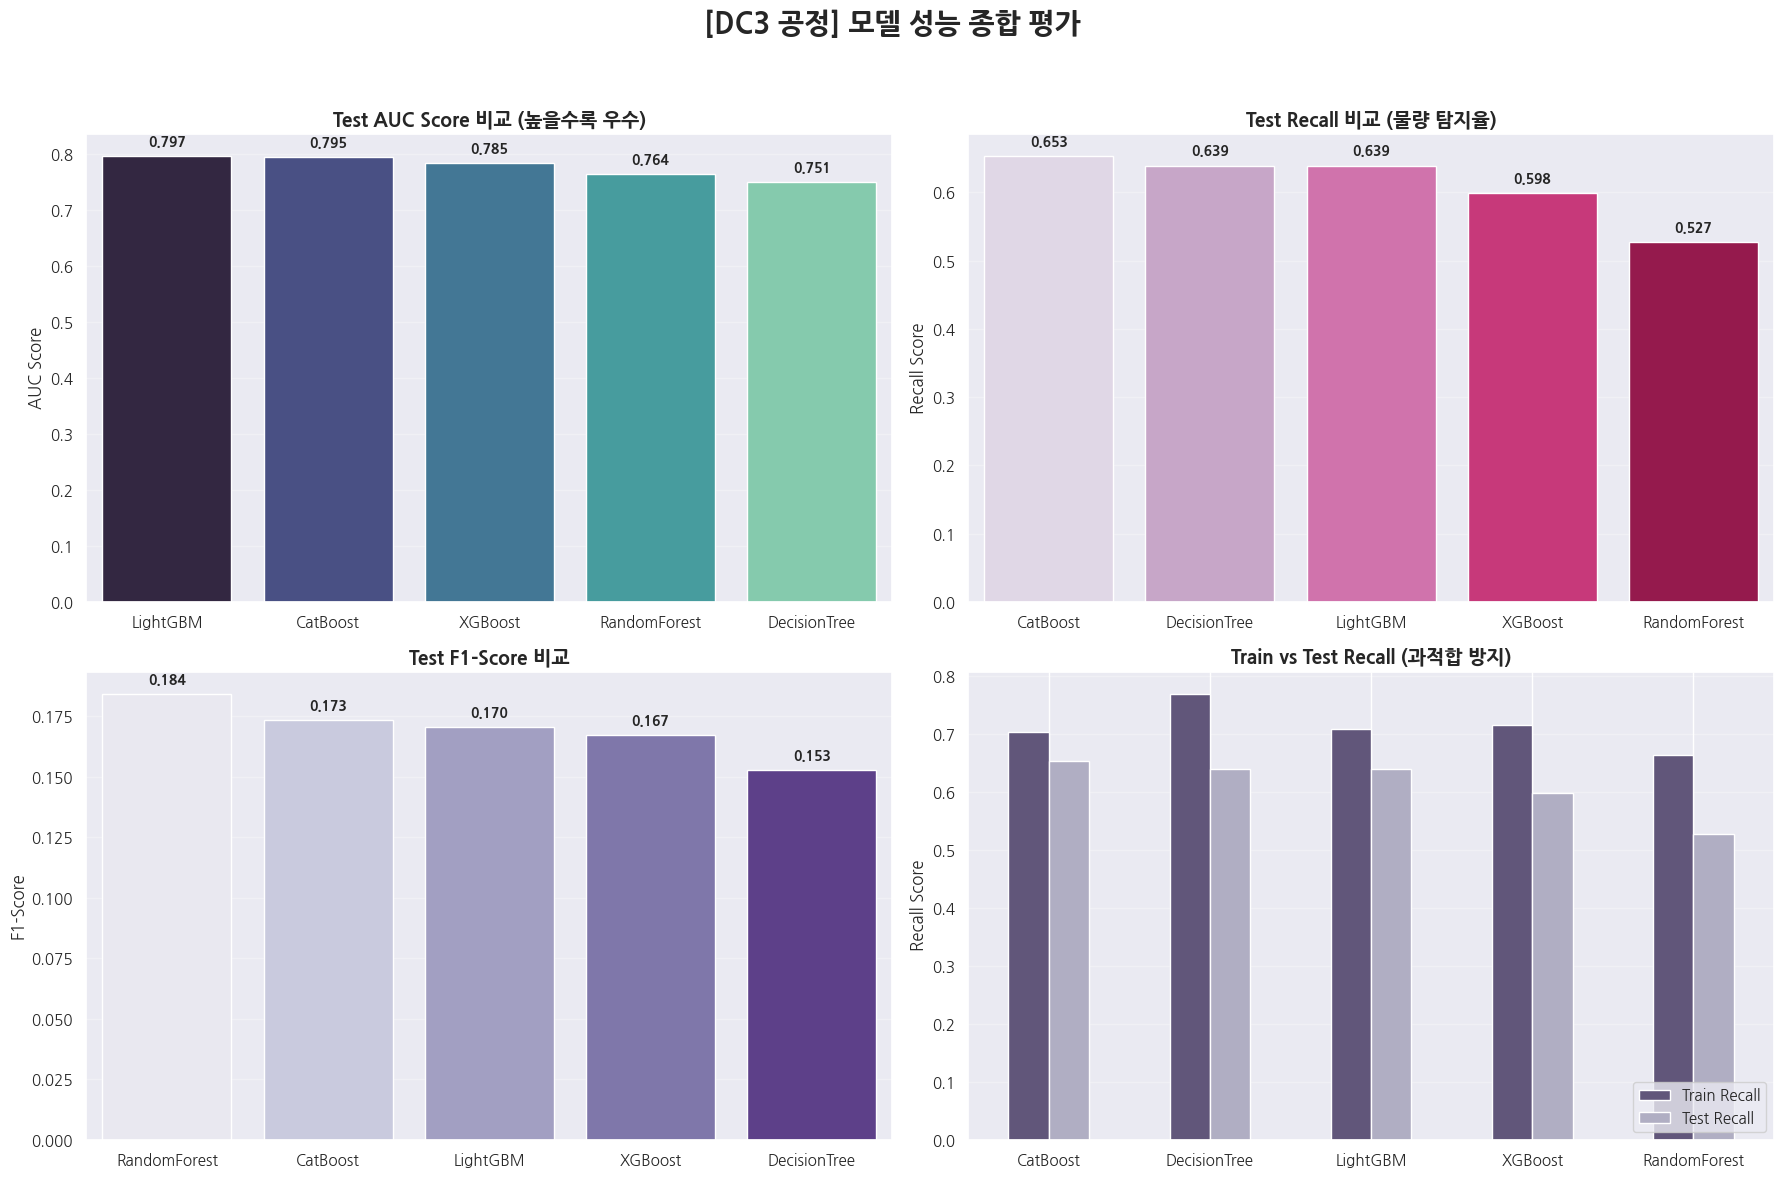


      [ DC3 공정 ] 2단계: 최적 모델 시뮬레이션
[DC3] 최적 모델로 'CatBoost' 선정 (Test Recall: 0.653)
[DC3] 시뮬레이션 실행 중... (제어 변수: dc3_temp_avg -> 280.25°C)

--- DC3 'CatBoost' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2394 개 (20.4511 %)
  개선 후 예상 불량 셀 수: 7 개 (0.0598 %)
  🔥 감소 효과: 2387 개 (불량률 20.3913 %p 감소)

      [ C4 공정 ] 1단계: 모델 성능 비교
[C4] 총 5개 모델 훈련 및 평가 시작...
  - DecisionTree 훈련 중...
  - RandomForest 훈련 중...
  - XGBoost 훈련 중...
  - LightGBM 훈련 중...
  - CatBoost 훈련 중...
[C4] 모델 평가 완료.

✅ [C4] 성능 비교 그래프 저장: C4_performance.png


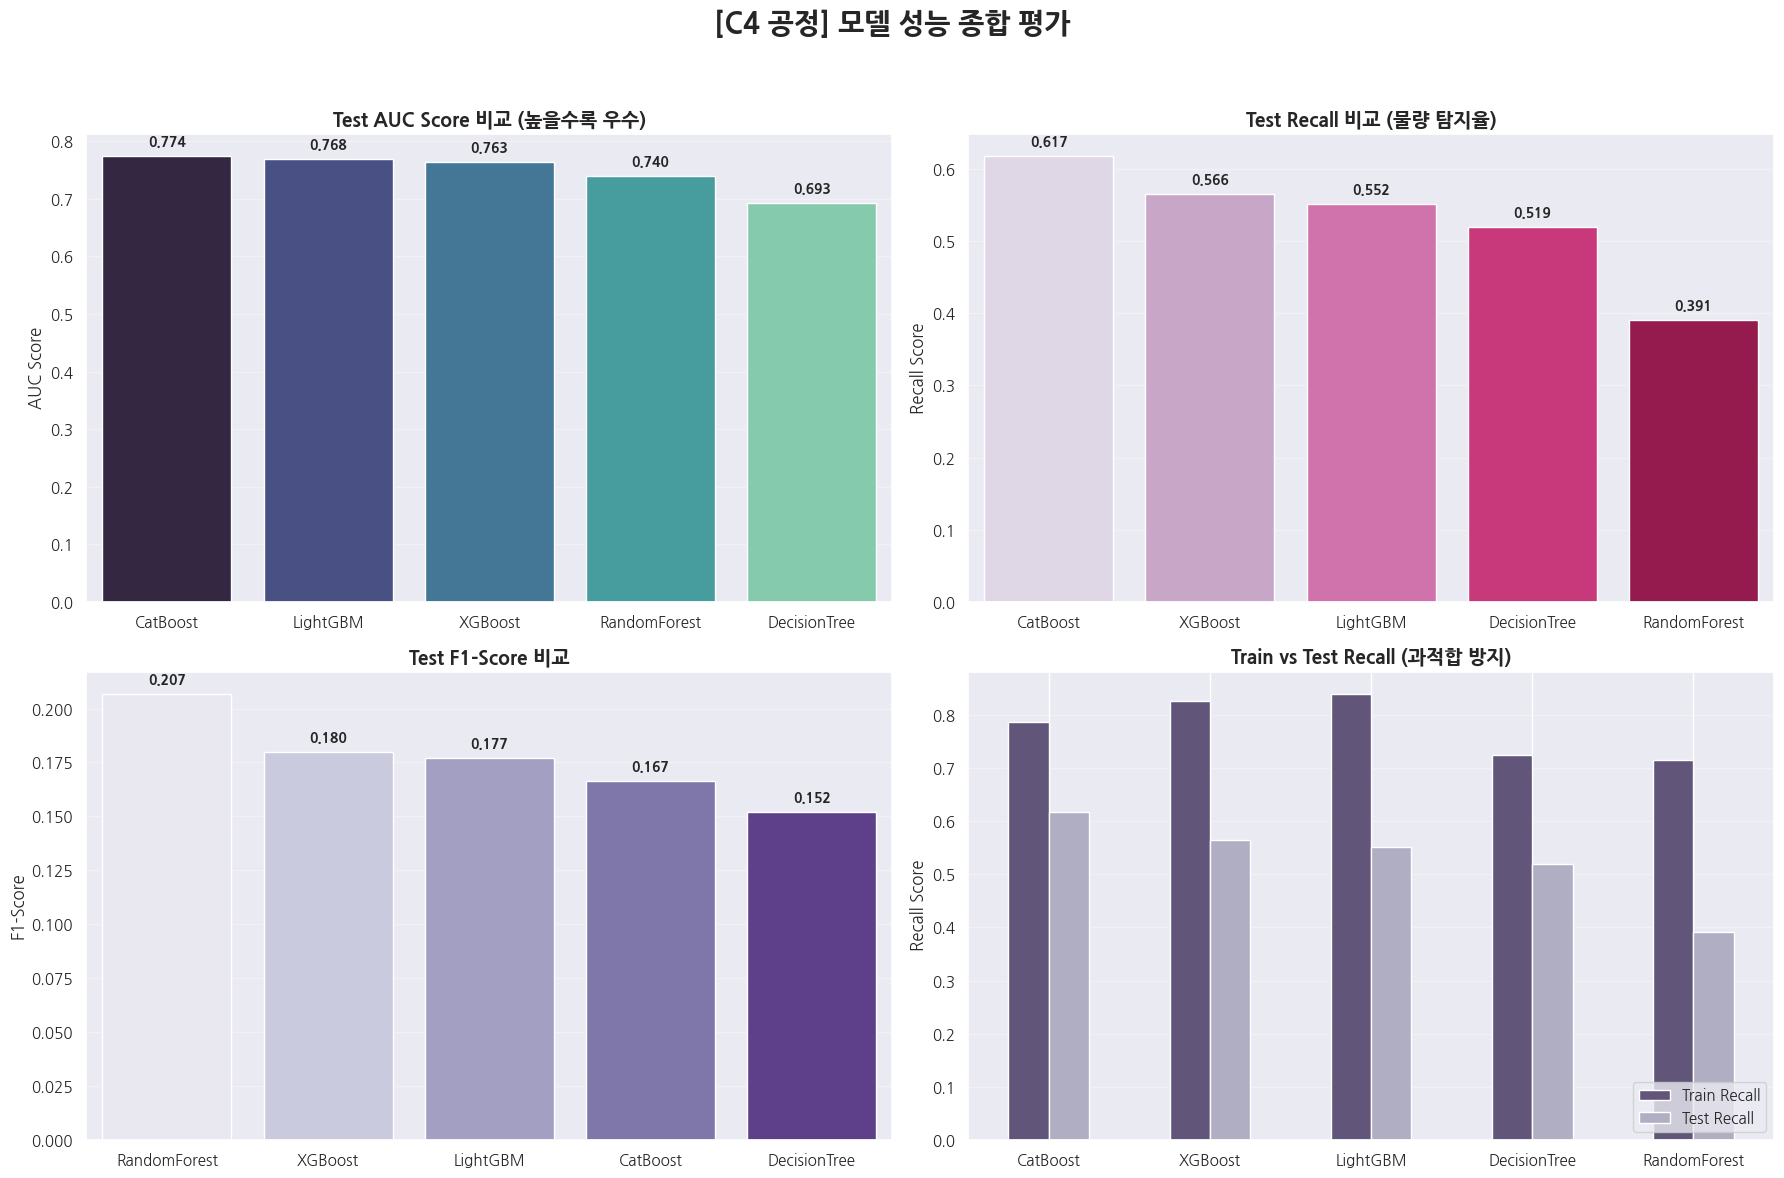


      [ C4 공정 ] 2단계: 최적 모델 시뮬레이션
[C4] 최적 모델로 'CatBoost' 선정 (Test Recall: 0.617)
[C4] 시뮬레이션 실행 중... (제어 변수: c4_temp_avg -> 280.25°C)

--- C4 'CatBoost' 모델 시뮬레이션 결과 ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  --------------------------------------------------
  현재 예상 불량 셀 수: 2347 개 (20.0495 %)
  개선 후 예상 불량 셀 수: 752 개 (6.4241 %)
  🔥 감소 효과: 1595 개 (불량률 13.6255 %p 감소)


      [ 최종 요약 ] 공정별 '최적 모델' 온도 제어 시뮬레이션 결과
     감소 개수         선정 모델  개선 후 불량률(%)
C1    2462      CatBoost     0.017085
DC3   2387      CatBoost     0.059798
DC1   1993      CatBoost     3.451222
C3    1834      CatBoost     5.715018
C2    1702      CatBoost     2.878866
C4    1595      CatBoost     6.424056
DC2    747  DecisionTree    18.494789

✅ 최종 요약 그래프 저장 완료: process_simulation_summary_best_models_purple_palette.png


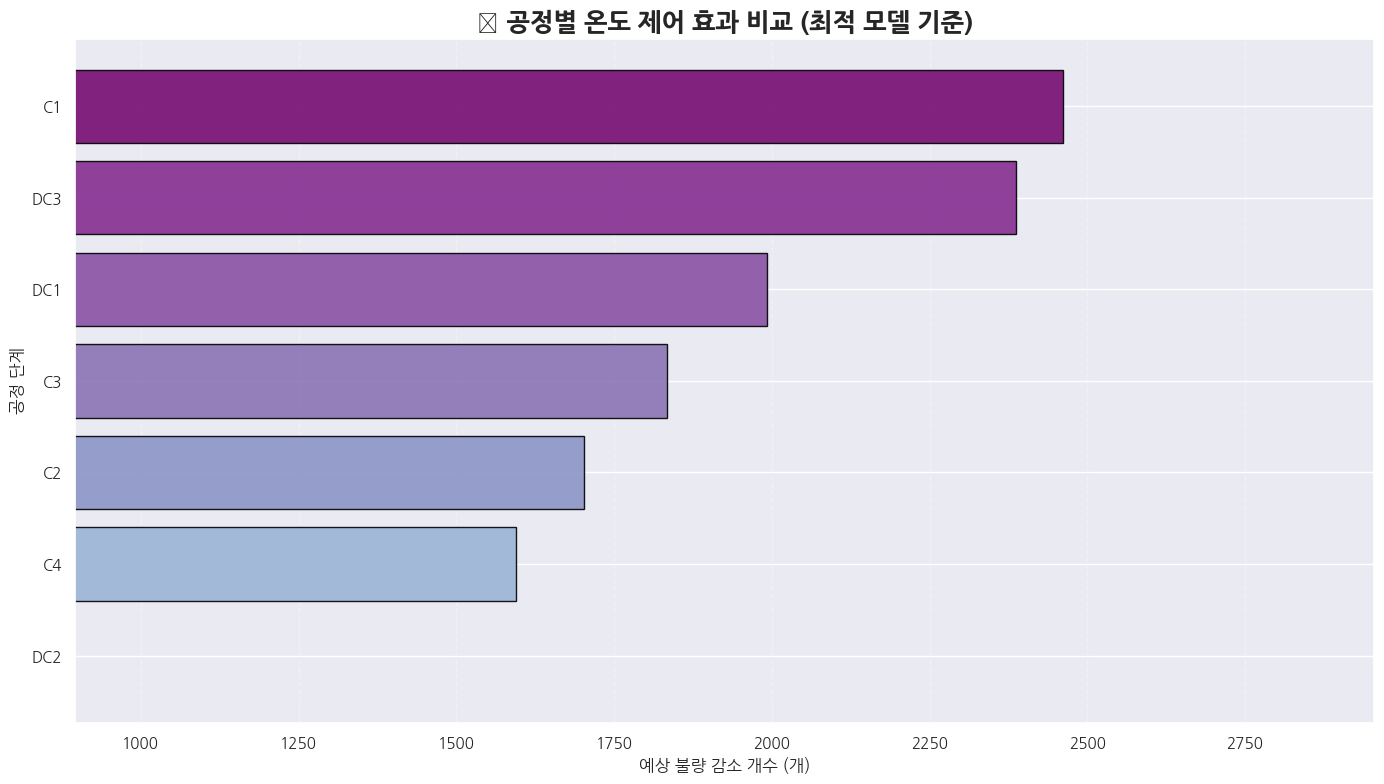

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# --- [0. 모델 라이브러리 임포트] ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier # (선택적)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
try:
    plt.rc('font', family='NanumGothic') # Windows
    # plt.rc('font', family='AppleGothic') # Mac
    plt.rc('axes', unicode_minus=False)
except:
    print("한글 폰트가 설치되어 있지 않습니다. 기본 폰트를 사용합니다.")


# ======================================================================
# [ 1. 사용자 설정 ]
# ======================================================================

FILE_PATH = 'final_cell_level_dataset.csv' 
TARGET_COLUMN = 'judge_encoded' 

OPTIMAL_TEMP_RANGES = {
    'c1_temp_avg': (265.5, 302.5),   
    'dc1_temp_avg': (265.0, 302.0),   
    'c2_temp_avg': (267.0, 304.0),   
    'dc2_temp_avg': (264.5, 301.5),  
    'c3_temp_avg': (262.0, 298.5),   
    'dc3_temp_avg': (262.0, 298.5),   
    'c4_temp_avg': (262.0, 298.5)    
}

OPTIMAL_TEMP_TARGETS = {
    key: (value[0] + value[1]) / 2 
    for key, value in OPTIMAL_TEMP_RANGES.items()
}

print("--- [시뮬레이션 설정] 공정별 최적 온도 (범위의 중간값) ---")
for key, value in OPTIMAL_TEMP_TARGETS.items():
    print(f"  ✅ {key}: {value:.2f}°C")
print("-------------------------------------------------")

# (이하 4-1, 4-2, 4-3 섹션은 원본 코드와 동일하게 유지...)
# 4-1. 데이터 생성 스크립트에서 가져온 변수 목록 (TAT 등은 제외됨)
metrics_to_keep = [
    'c1_temp_avg', 'dc1_temp_avg', 'c2_temp_avg', 'dc2_temp_avg', 'c3_temp_avg', 'dc3_temp_avg', 'c4_temp_avg', 
    'c1_capa', 'dc1_capa', 'c2_capa', 'dc2_capa', 'c3_capa', 'dc3_capa', 'c4_capa',
    'c1_curr_end', 'dc1_curr_end', 'c2_curr_end', 'dc2_curr_end', 'c3_curr_end', 'dc3_curr_end', 'c4_curr_end', 
    'c1_ccval', 'c2_ccval', 'c3_ccval', 'c4_ccval', 'c3_cvval', 'c4_cvval',
    'c1_voltage_avg', 'dc1_voltage_avg', 'c2_voltage_avg', 'dc2_voltage_avg', 'c3_voltage_avg', 'dc3_voltage_avg', 'c4_voltage_avg', 
    'c1_time_cc', 'c2_time_cc', 'c3_time_cc', 'c4_time_cc', 'c3_time_cv', 'c4_time_cv',
    'dc1_capafit', 'dc2_capafit', 'dc3_capafit', 
    'pg1_impfit', 'pg1_imp', 'pc1_imp', 
    'pg1_voltage_start', 'pc1_voltage_start',
    'ocv1_ocv', 'ocv2_ocv', 'socv1_ocv', 'socv2_ocv', 'socv3_ocv', 'ocv2_deltaocv', 'ocv1_deltaocv',
    'm1_thick', 'm1_voltage', 'm1_res_ac', 'm1_mv', 'm1_voltage_an',
    'rta1_cell_no' 
]
# 4-2. 타겟 누수(Leakage)를 유발하는 변수 키워드 목록
LEAKAGE_KEYWORDS = ['_capa', '_capafit', '_imp', 'res_ac', '_ocv']
# 4-3. 분석 대상 7개 공정
STAGES = ['c1', 'dc1', 'c2', 'dc2', 'c3', 'dc3', 'c4']

process_features_config = {}
print("--- [시뮬레이션 설정] 공정별 변수 자동 구성 ---")
for stage in STAGES:
    stage_name = stage.upper()
    temp_col_name = f"{stage}_temp_avg"
    stage_vars = [col for col in metrics_to_keep if col.startswith(stage + '_')]
    filtered_vars = []
    for var in stage_vars:
        is_leakage = False
        for keyword in LEAKAGE_KEYWORDS:
            if keyword in var:
                is_leakage = True
                break
        if not is_leakage:
            filtered_vars.append(var)
    if temp_col_name not in filtered_vars:
        print(f"[경고] {stage_name}의 온도 변수 '{temp_col_name}'가 없습니다.")
    elif not filtered_vars:
        print(f"[경고] {stage_name}에 사용할 수 있는 (누수 제외) 변수가 없습니다.")
    else:
        process_features_config[stage_name] = {
            'vars': filtered_vars,
            'temp_col': temp_col_name
        }
        print(f"  ✅ {stage_name} 모델: {len(filtered_vars)}개 변수 사용 (제어 변수: {temp_col_name})")
print("-------------------------------------------------")


# ======================================================================
# [ 2. 데이터 로드 및 전처리 ]
# ======================================================================
try:
    data = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"[오류] 파일을 찾을 수 없습니다: {FILE_PATH}")
    # exit() # In a notebook environment, don't exit
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    # exit()

# [수정] exit()가 없으므로, data가 로드되었는지 확인하는 절차 추가
if 'data' not in locals():
    print("[오류] 데이터가 로드되지 않아 스크립트를 중단합니다.")
else:
    all_required_cols = set([TARGET_COLUMN])
    for config in process_features_config.values():
        all_required_cols.update(config['vars'])

    original_rows = len(data)
    data = data[list(all_required_cols)].dropna()
    print(f"데이터 로드 완료. (원본 {original_rows}개 행 -> NaN 제거 후 {len(data)}개 행 사용)")
    print(f"전체 데이터 실제 불량률: {data[TARGET_COLUMN].mean() * 100 :.2f} %")


    # ======================================================================
    # [ 3. 모델 정의 (새로 추가된 섹션) ]
    # ======================================================================
    # (이 섹션은 수정 없음)
    def get_models(scale_pos_weight):
        models = {
            'DecisionTree': DecisionTreeClassifier(
                max_depth=10, 
                random_state=42, 
                class_weight='balanced'
            ),
            'RandomForest': RandomForestClassifier(
                n_estimators=100, 
                max_depth=10, 
                random_state=42, 
                class_weight='balanced',
                n_jobs=-1
            ),
            'XGBoost': xgb.XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
                early_stopping_rounds=50
            ),
            'LightGBM': lgb.LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
                verbose=-1
            ),
            'CatBoost': CatBoostClassifier(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                scale_pos_weight=scale_pos_weight,
                random_seed=42,
                verbose=0,
                allow_writing_files=False
            )
        }
        return models


    # ======================================================================
    # [ 4. 공정별 모델 선정 및 시뮬레이션 루프 (수정됨) ]
    # ======================================================================
    simulation_summary = {} 

    try:
        y = data[TARGET_COLUMN]
    except KeyError:
        print(f"[치명적 오류] 타겟 컬럼 '{TARGET_COLUMN}'을(를) 데이터에서 찾을 수 없습니다.")
        # exit()

    # [외부 루프] 7개 공정 순회
    for process_name, config in process_features_config.items():
        
        print("\n" + "="*80)
        print(f"      [ {process_name} 공정 ] 1단계: 모델 성능 비교")
        print("="*80)

        try:
            # 1. X, y 데이터 선택 및 분리
            feature_vars = config['vars']
            temp_col_name = config['temp_col']
            X = data[feature_vars]

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )
            
            # 2. 모델 훈련을 위한 설정
            scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
            models_to_train = get_models(scale_pos_weight)
            
            performance_metrics = {} 
            trained_models = {}      

            # [내부 루프] C1 데이터로 5개 모델 모두 훈련
            print(f"[{process_name}] 총 {len(models_to_train)}개 모델 훈련 및 평가 시작...")
            for model_name, model in models_to_train.items():
                print(f"  - {model_name} 훈련 중...")
                
                if model_name in ['XGBoost', 'LightGBM']:
                    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=0)
                else:
                    model.fit(X_train, y_train)
                    
                trained_models[model_name] = model 
                
                pred_train = model.predict(X_train)
                prob_train = model.predict_proba(X_train)[:, 1]
                pred_test = model.predict(X_test)
                prob_test = model.predict_proba(X_test)[:, 1]
                
                performance_metrics[model_name] = {
                    'Train AUC': roc_auc_score(y_train, prob_train),
                    'Test AUC': roc_auc_score(y_test, prob_test),
                    'Train Recall': recall_score(y_train, pred_train),
                    'Test Recall': recall_score(y_test, pred_test),
                    'Train F1-Score': f1_score(y_train, pred_train),
                    'Test F1-Score': f1_score(y_test, pred_test)
                }
            
            print(f"[{process_name}] 모델 평가 완료.")

# 3. [시각화 1] 모델 성능 종합 비교
            df_performance = pd.DataFrame(performance_metrics).T
            
            fig, axes = plt.subplots(2, 2, figsize=(18, 12))
            fig.suptitle(f'[{process_name} 공정] 모델 성능 종합 평가', fontsize=20, fontweight='bold', y=0.98)
            
            def add_text_labels(ax, data_series):
                ymin, ymax = ax.get_ylim()
                offset = (ymax - ymin) * 0.015 
                for i, v in enumerate(data_series):
                    ax.text(i, v + offset, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

            # 1. AUC 비교
            ax1 = axes[0, 0]
            df_auc = df_performance.sort_values('Test AUC', ascending=False)
            # [수정] 'viridis' -> 'mako' (어두운 보라/청록 계열)
            sns.barplot(x=df_auc.index, y='Test AUC', data=df_auc, ax=ax1, palette="mako")
            ax1.set_title('Test AUC Score 비교 (높을수록 우수)', fontsize=14, fontweight='bold')
            ax1.set_ylabel('AUC Score')
            add_text_labels(ax1, df_auc['Test AUC'])
            ax1.grid(axis='y', alpha=0.3)
            
            # 2. Recall 비교
            ax2 = axes[0, 1]
            df_recall = df_performance.sort_values('Test Recall', ascending=False)
            # [수정] 'magma' -> 'PuRd' (보라 -> 붉은 계열)
            sns.barplot(x=df_recall.index, y='Test Recall', data=df_recall, ax=ax2, palette="PuRd")
            ax2.set_title('Test Recall 비교 (불량 탐지율)', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Recall Score')
            add_text_labels(ax2, df_recall['Test Recall'])
            ax2.grid(axis='y', alpha=0.3)

            # 3. F1-Score 비교
            ax3 = axes[1, 0]
            df_f1 = df_performance.sort_values('Test F1-Score', ascending=False)
            # [수정] 'Reds' -> 'Purples' (보라색 단일 계열)
            sns.barplot(x=df_f1.index, y='Test F1-Score', data=df_f1, ax=ax3, palette="Purples")
            ax3.set_title('Test F1-Score 비교', fontsize=14, fontweight='bold')
            ax3.set_ylabel('F1-Score')
            add_text_labels(ax3, df_f1['Test F1-Score'])
            ax3.grid(axis='y', alpha=0.3)
            
            # 4. Train vs Test Recall 비교
            ax4 = axes[1, 1]
            df_recall_comp = df_performance[['Train Recall', 'Test Recall']].sort_values('Test Recall', ascending=False)
            # [수정] 단일 색상 -> 2가지 보라색 계열로 변경
            # (진한 보라색, 연한 보라색)
            colors_list = ["#61567A", "#B0AEC3"] 
            df_recall_comp.plot(kind='bar', ax=ax4, color=colors_list) 
            ax4.set_title('Train vs Test Recall (과적합 방지)', fontsize=14, fontweight='bold')
            ax4.set_ylabel('Recall Score')
            ax4.set_xticklabels(df_recall_comp.index, rotation=0)
            ax4.legend(loc='lower right')
            ax4.grid(axis='y', alpha=0.3)

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            save_filename = f'{process_name}_performance.png'
            plt.savefig(save_filename, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"\n✅ [{process_name}] 성능 비교 그래프 저장: {save_filename}")
            plt.show()
                
            # 4. [시뮬레이션]
            print("\n" + "="*80)
            print(f"      [ {process_name} 공정 ] 2단계: 최적 모델 시뮬레이션")
            print("="*80)
            
            best_model_name = df_performance['Test Recall'].idxmax()
            best_model = trained_models[best_model_name]
            print(f"[{process_name}] 최적 모델로 '{best_model_name}' 선정 (Test Recall: {df_performance.loc[best_model_name, 'Test Recall']:.3f})")
            
            current_optimal_temp = OPTIMAL_TEMP_TARGETS.get(temp_col_name)
            if current_optimal_temp is None:
                print(f"[경고] {process_name} ({temp_col_name})에 대한 최적 온도가 없습니다. 시뮬레이션을 건너뜁니다.")
                continue
                
            print(f"[{process_name}] 시뮬레이션 실행 중... (제어 변수: {temp_col_name} -> {current_optimal_temp:.2f}°C)")
            
            pred_original = best_model.predict(X_test)
            defect_count_original = np.sum(pred_original)
            defect_rate_original = defect_count_original / len(X_test) * 100

            X_test_simulated = X_test.copy()
            X_test_simulated[temp_col_name] = current_optimal_temp
            
            pred_simulated = best_model.predict(X_test_simulated)
            defect_count_simulated = np.sum(pred_simulated)
            defect_rate_simulated = defect_count_simulated / len(X_test) * 100

            reduction_count = defect_count_original - defect_count_simulated
            reduction_rate = defect_rate_original - defect_rate_simulated

            print(f"\n--- {process_name} '{best_model_name}' 모델 시뮬레이션 결과 ---")
            print(f"  실제 불량 개수 (Test Set): {np.sum(y_test)} 개 ({y_test.mean() * 100 :.4f} %)")
            print(f"  --------------------------------------------------")
            print(f"  현재 예상 불량 셀 수: {defect_count_original} 개 ({defect_rate_original:.4f} %)")
            print(f"  개선 후 예상 불량 셀 수: {defect_count_simulated} 개 ({defect_rate_simulated:.4f} %)")
            print(f"  🔥 감소 효과: {reduction_count} 개 (불량률 {reduction_rate:.4f} %p 감소)")
            
            simulation_summary[process_name] = {
                '감소 개수': reduction_count,
                '선정 모델': best_model_name,
                '개선 후 불량률(%)': defect_rate_simulated
            }

        except Exception as e:
            print(f"\n[오류] {process_name} 공정 처리 중 오류 발생: {e}")
            import traceback
            traceback.print_exc()


    # ======================================================================
# [ 5. 최종 결과 요약 및 시각화 ]
# ======================================================================

if simulation_summary:
    print("\n\n" + "="*80)
    print("      [ 최종 요약 ] 공정별 '최적 모델' 온도 제어 시뮬레이션 결과")
    print("="*80)
    
    df_summary = pd.DataFrame.from_dict(simulation_summary, orient='index')
    df_summary = df_summary.sort_values(by='감소 개수', ascending=False)
    
    print(df_summary)
    
    plt.figure(figsize=(14, 8))
    df_summary_sorted = df_summary.sort_values(by='감소 개수', ascending=True)
    
    # [수정] '보라색 계열' 팔레트 적용
    colors_gradient = plt.cm.BuPu(np.linspace(0.3, 0.9, len(df_summary_sorted)))
    bars = plt.barh(df_summary_sorted.index, df_summary_sorted['감소 개수'], color=colors_gradient , alpha=0.9, edgecolor='black')
    
    plt.title(f'🔥 공정별 온도 제어 효과 비교 (최적 모델 기준)', fontsize=18, fontweight='bold')
    plt.xlabel('예상 불량 감소 개수 (개)', fontsize=12)
    plt.ylabel('공정 단계', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    max_val = df_summary['감소 개수'].max()
    min_val = df_summary['감소 개수'].min()
    
    for bar in bars:
        # --- [오류 수정] ---
        # bar.get_label()이 '_nolegend_'를 반환하는 경우 건너뛰기
        label = bar.get_label()
        if label.startswith('_'):
            continue
        # ---------------------
            
        width = bar.get_width()
        
        # [수정] label 변수 사용
        model_name = df_summary_sorted.loc[label, '선정 모델'] 
        
        if width < 0:
            label_x_pos = width - (max_val * 0.02)
            ha = 'right'
            color = 'red' 
            text = f"{width} 개 (악화) [{model_name}]"
        else:
            label_x_pos = width + (max_val * 0.02)
            ha = 'left'
            color = "#61567A" 
            text = f"+{width} 개 감소 [{model_name}]"
            
        plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, text, 
                 va='center', ha=ha, fontsize=10, fontweight='bold', color=color )

    max_abs_val = max(abs(min_val), abs(max_val))
    if max_abs_val > 0 : 
        plt.xlim(min_val * 1.2, max_abs_val * 1.2) 
    else:
        plt.xlim(-1, 1)

    plt.tight_layout()
    plt.savefig('process_simulation_summary_best_models_purple_palette.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("\n✅ 최종 요약 그래프 저장 완료: process_simulation_summary_best_models_purple_palette.png")
    plt.show()

else:
    print("\n[알림] 시뮬레이션이 정상적으로 실행되지 않아 요약할 결과가 없습니다.")

## 불량률 개선

## 분류

--- [시뮬레이션 설정] 공정별 최적 온도 (범위의 중간값) ---
  ✅ c1_temp_avg: 28.4°C
  ✅ dc1_temp_avg: 28.4°C
  ✅ c2_temp_avg: 28.6°C
  ✅ dc2_temp_avg: 28.3°C
  ✅ c3_temp_avg: 28.0°C
  ✅ dc3_temp_avg: 28.0°C
  ✅ c4_temp_avg: 28.0°C
-------------------------------------------------
--- [시뮬레이션 설정] 공정별 변수 자동 구성 ---
  ✅ C1 모델: 5개 변수 사용 (제어 변수: c1_temp_avg)
  ✅ DC1 모델: 3개 변수 사용 (제어 변수: dc1_temp_avg)
  ✅ C2 모델: 5개 변수 사용 (제어 변수: c2_temp_avg)
  ✅ DC2 모델: 3개 변수 사용 (제어 변수: dc2_temp_avg)
  ✅ C3 모델: 7개 변수 사용 (제어 변수: c3_temp_avg)
  ✅ DC3 모델: 3개 변수 사용 (제어 변수: dc3_temp_avg)
  ✅ C4 모델: 7개 변수 사용 (제어 변수: c4_temp_avg)
-------------------------------------------------
데이터 로드 완료. (원본 39019개 행 -> NaN 제거 후 39019개 행 사용)
전체 데이터 실제 불량률: 3.13 %

      [ C1 (개별) 공정 ] 모델 훈련 및 시뮬레이션
[C1] [경고] Train/Test 분리 없이 전체 데이터(39019개)로 훈련 및 평가를 진행합니다.
[C1] 모델 훈련 중... (Train: 39019개, Test: 39019개)
[C1] '보정 임계값' 계산 완료: 0.8378 (이 값 이상을 '불량'으로 판단)
[C1] 시뮬레이션 실행 중... (제어 변수: c1_temp_avg -> 284.00°C)

--- C1 (개별) 모델 시뮬레이션 결과 (보정됨) ---
  실제 불량 개수 (전체 데이터

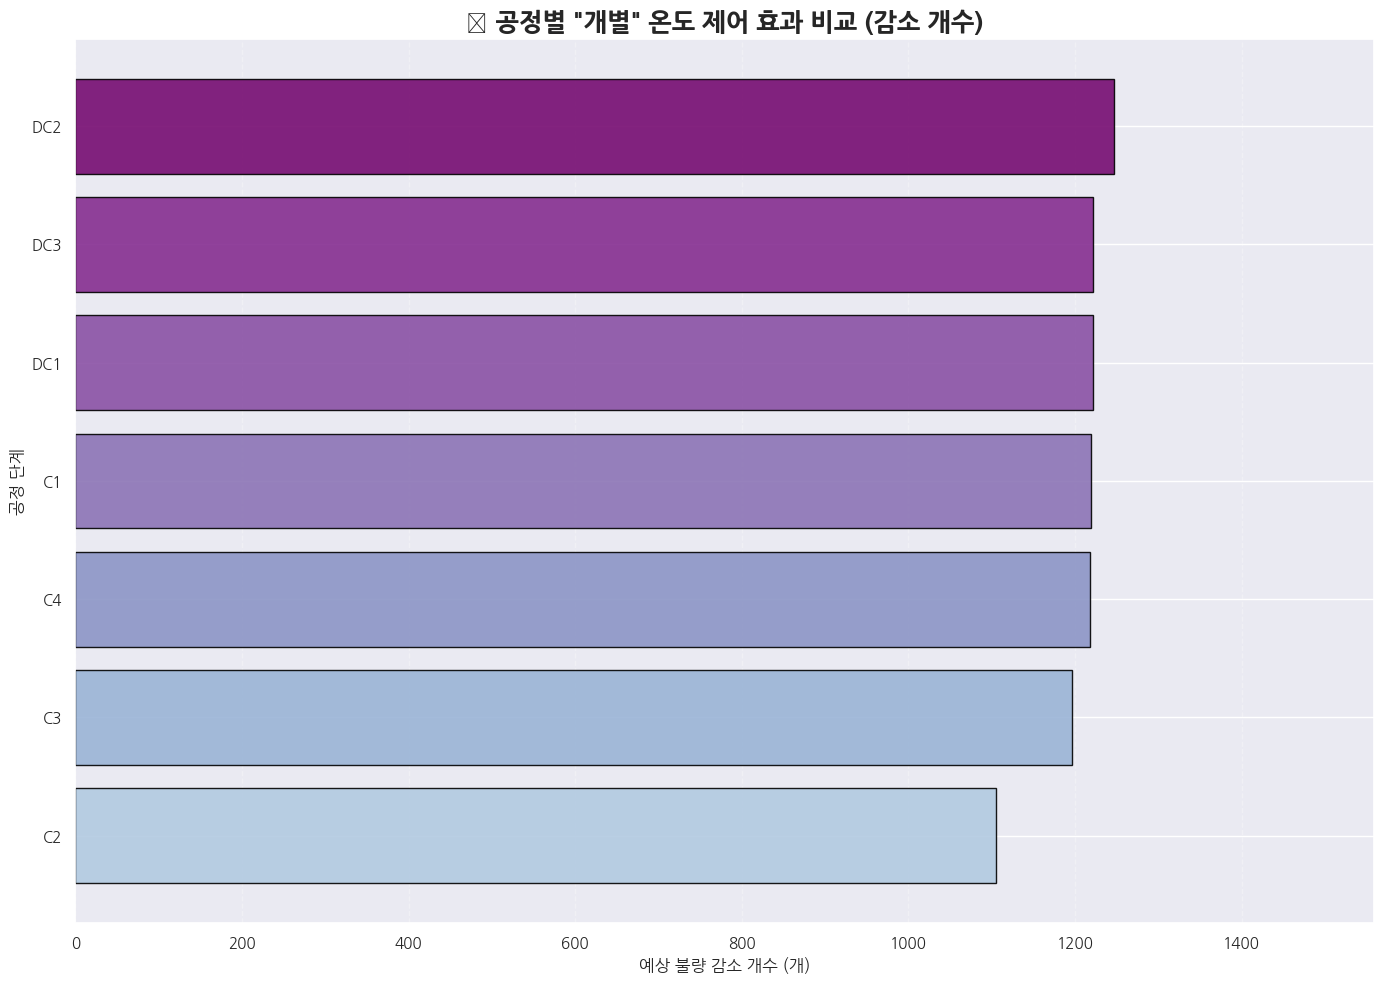

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import warnings
import traceback # 오류 추적을 위해 추가

# 경고 메시지 무시
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (환경에 맞게 수정)
try:
    plt.rc('font', family='NanumGothic')
    plt.rc('axes', unicode_minus=False) # 마이너스 부호 깨짐 방지
except:
    print("Malgun Gothic 폰트가 설치되어 있지 않습니다. 기본 폰트를 사용합니다.")


# ======================================================================
# [ 1. 사용자 설정 ]
# ======================================================================

FILE_PATH = 'final_cell_level_dataset.csv' 
TARGET_COLUMN = 'judge_encoded' 

OPTIMAL_TEMP_RANGES = {
    'c1_temp_avg': (265.5, 302.5),   
    'dc1_temp_avg': (265.0, 302.0),   
    'c2_temp_avg': (267.0, 304.0),   
    'dc2_temp_avg': (264.5, 301.5),  
    'c3_temp_avg': (262.0, 298.5),   
    'dc3_temp_avg': (262.0, 298.5),   
    'c4_temp_avg': (262.0, 298.5)    
}

OPTIMAL_TEMP_TARGETS = {
    key: (value[0] + value[1]) / 2 
    for key, value in OPTIMAL_TEMP_RANGES.items()
}

print("--- [시뮬레이션 설정] 공정별 최적 온도 (범위의 중간값) ---")
for key, value in OPTIMAL_TEMP_TARGETS.items():
    # [수정] 요청하신 대로 print 문에서만 10으로 나누어 표시
    print(f"  ✅ {key}: {value / 10:.1f}°C") 
print("-------------------------------------------------")

# (4-1, 4-2, 4-3 섹션은 원본과 동일)
metrics_to_keep = [
    'c1_temp_avg', 'dc1_temp_avg', 'c2_temp_avg', 'dc2_temp_avg', 'c3_temp_avg', 'dc3_temp_avg', 'c4_temp_avg', 
    'c1_capa', 'dc1_capa', 'c2_capa', 'dc2_capa', 'c3_capa', 'dc3_capa', 'c4_capa',
    'c1_curr_end', 'dc1_curr_end', 'c2_curr_end', 'dc2_curr_end', 'c3_curr_end', 'dc3_curr_end', 'c4_curr_end', 
    'c1_ccval', 'c2_ccval', 'c3_ccval', 'c4_ccval', 'c3_cvval', 'c4_cvval',
    'c1_voltage_avg', 'dc1_voltage_avg', 'c2_voltage_avg', 'dc2_voltage_avg', 'c3_voltage_avg', 'dc3_voltage_avg', 'c4_voltage_avg', 
    'c1_time_cc', 'c2_time_cc', 'c3_time_cc', 'c4_time_cc', 'c3_time_cv', 'c4_time_cv',
    'dc1_capafit', 'dc2_capafit', 'dc3_capafit', 
    'pg1_impfit', 'pg1_imp', 'pc1_imp', 
    'pg1_voltage_start', 'pc1_voltage_start',
    'ocv1_ocv', 'ocv2_ocv', 'socv1_ocv', 'socv2_ocv', 'socv3_ocv', 'ocv2_deltaocv', 'ocv1_deltaocv',
    'm1_thick', 'm1_voltage', 'm1_res_ac', 'm1_mv', 'm1_voltage_an',
    'rta1_cell_no' 
]
LEAKAGE_KEYWORDS = ['_capa', '_capafit', '_imp', 'res_ac', '_ocv']
STAGES = ['c1', 'dc1', 'c2', 'dc2', 'c3', 'dc3', 'c4']
process_features_config = {}
print("--- [시뮬레이션 설정] 공정별 변수 자동 구성 ---")
for stage in STAGES:
    stage_name = stage.upper()
    temp_col_name = f"{stage}_temp_avg"
    stage_vars = [col for col in metrics_to_keep if col.startswith(stage + '_')]
    filtered_vars = []
    for var in stage_vars:
        is_leakage = False
        for keyword in LEAKAGE_KEYWORDS:
            if keyword in var:
                is_leakage = True
                break
        if not is_leakage:
            filtered_vars.append(var)
    if temp_col_name not in filtered_vars:
        print(f"[경고] {stage_name}의 온도 변수 '{temp_col_name}'가 없습니다.")
    elif not filtered_vars:
        print(f"[경고] {stage_name}에 사용할 수 있는 (누수 제외) 변수가 없습니다.")
    else:
        process_features_config[stage_name] = {
            'vars': filtered_vars,
            'temp_col': temp_col_name
        }
        print(f"  ✅ {stage_name} 모델: {len(filtered_vars)}개 변수 사용 (제어 변수: {temp_col_name})")
print("-------------------------------------------------")


# ======================================================================
# [ 2. 데이터 로드 및 전처리 ]
# ======================================================================
try:
    data = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"[오류] 파일을 찾을 수 없습니다: {FILE_PATH}")
    exit()
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    exit()

all_required_cols = set([TARGET_COLUMN])
for config in process_features_config.values():
    all_required_cols.update(config['vars'])

original_rows = len(data)
data = data[list(all_required_cols)].dropna()
print(f"데이터 로드 완료. (원본 {original_rows}개 행 -> NaN 제거 후 {len(data)}개 행 사용)")
print(f"전체 데이터 실제 불량률: {data[TARGET_COLUMN].mean() * 100 :.2f} %")


# ======================================================================
# [ 3. 공정별 '개별' 모델 훈련 및 시뮬레이션 루프 (보정 임계값 적용) ]
# ======================================================================

simulation_summary = {} # 개별 공정 시뮬레이션 결과 저장

try:
    y = data[TARGET_COLUMN]
except KeyError:
    print(f"[치명적 오류] 타겟 컬럼 '{TARGET_COLUMN}'을(를) 데이터에서 찾을 수 없습니다.")
    exit()

for process_name, config in process_features_config.items():
    
    print("\n" + "="*60)
    print(f"      [ {process_name} (개별) 공정 ] 모델 훈련 및 시뮬레이션")
    print("="*60)

    try:
        # 1. 해당 공정의 X, y 데이터 선택
        feature_vars = config['vars']
        temp_col_name = config['temp_col']
        X = data[feature_vars]

        # 2. Train/Test 분리 없이 전체 데이터 사용
        X_train = X
        y_train = y
        X_test = X  # 훈련 데이터를 그대로 테스트(시뮬레이션)에 사용
        y_test = y  # 훈련 데이터를 그대로 테스트(시뮬레이션)에 사용
        
        print(f"[{process_name}] [경고] Train/Test 분리 없이 전체 데이터({len(X_train)}개)로 훈련 및 평가를 진행합니다.")
        
        # 3. 모델 훈련
        print(f"[{process_name}] 모델 훈련 중... (Train: {len(X_train)}개, Test: {len(X_test)}개)")
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        
        model = CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6,
            scale_pos_weight=scale_pos_weight,
            random_seed=42, verbose=0, allow_writing_files=False
        )
        model.fit(X_train, y_train)

        # 4. [수정] 시뮬레이션 실행 (보정 임계값 적용)
        
        # 4-1. [수정] '보정 임계값' 계산
        prob_train_original = model.predict_proba(X_train)[:, 1]
        target_defect_rate = y_train.mean() 
        threshold_calibrated = np.percentile(prob_train_original, 100 * (1 - target_defect_rate))
        
        print(f"[{process_name}] '보정 임계값' 계산 완료: {threshold_calibrated:.4f} (이 값 이상을 '불량'으로 판단)")

        # 4-2. 목표 온도 가져오기
        current_optimal_temp = OPTIMAL_TEMP_TARGETS.get(temp_col_name)
        if current_optimal_temp is None:
            print(f"[경고] {process_name} ({temp_col_name})의 최적 온도가 없습니다. 건너뜁니다.")
            continue
            
        print(f"[{process_name}] 시뮬레이션 실행 중... (제어 변수: {temp_col_name} -> {current_optimal_temp:.2f}°C)")
        
        # 4-3. [수정] (원본) 현재 조건 예측 (확률에 보정 임계값 적용)
        prob_original = model.predict_proba(X_test)[:, 1]
        pred_original = (prob_original >= threshold_calibrated).astype(int)
        defect_count_original = np.sum(pred_original)
        defect_rate_original = defect_count_original / len(X_test) * 100

        # 4-4. (시뮬레이션) 온도 강제 제어
        X_test_simulated = X_test.copy()
        X_test_simulated[temp_col_name] = current_optimal_temp
        
        # 4-5. [수정] (개선 후) 예측 (확률에 보정 임계값 적용)
        prob_simulated = model.predict_proba(X_test_simulated)[:, 1]
        pred_simulated = (prob_simulated >= threshold_calibrated).astype(int)
        defect_count_simulated = np.sum(pred_simulated)
        defect_rate_simulated = defect_count_simulated / len(X_test) * 100


        # 5. 결과 요약 및 저장
        reduction_count = defect_count_original - defect_count_simulated
        reduction_rate = defect_rate_original - defect_rate_simulated

        print(f"\n--- {process_name} (개별) 모델 시뮬레이션 결과 (보정됨) ---")
        print(f"  실제 불량 개수 (전체 데이터): {np.sum(y_test)} 개 ({y_test.mean() * 100 :.4f} %)")
        print(f"  --------------------------------------------------")
        print(f"  현재 예상 불량 셀 수: {defect_count_original} 개 ({defect_rate_original:.4f} %)")
        print(f"  개선 후 예상 불량 셀 수: {defect_count_simulated} 개 ({defect_rate_simulated:.4f} %)")
        print(f"  🔥 감소 효과: {reduction_count} 개 (불량률 {reduction_rate:.4f} %p 감소)")
        
        simulation_summary[process_name] = {
            '감소 개수': reduction_count,
            '현재 불량률(%)': defect_rate_original,
            '개선 후 불량률(%)': defect_rate_simulated
        }

    except KeyError as e:
        print(f"\n[치명적 오류] {process_name} 공정 처리 중 컬럼명 오류 발생: {e}")
    except Exception as e:
        print(f"\n[오류] {process_name} 공정 처리 중 알 수 없는 오류 발생: {e}")
        traceback.print_exc()

# ======================================================================
# [ 4. '전체 공정' 통합 시뮬레이션 (보정 임계값 적용) ]
# ======================================================================
print("\n\n" + "="*80)
print("      [ '전체 공정' 통합 ] 1단계: 전체 변수 모델 훈련")
print("="*80)

try:
    # 1. '전체' X, y 데이터 선택
    all_feature_vars = list(all_required_cols - {TARGET_COLUMN})
    X_full = data[all_feature_vars]

    # 2. '전체' 데이터 분리 (Train/Test) 제거
    X_train_full = X_full
    y_train_full = y
    X_test_full = X_full
    y_test_full = y
    
    print(f"[전체 모델] [경고] Train/Test 분리 없이 전체 데이터({len(X_train_full)}개)로 훈련 및 평가를 진행합니다.")

    # 3. '전체' 모델 훈련 (CatBoost 사용)
    print(f"[전체 모델] 훈련 중... (Train: {len(X_train_full)}개, Test: {len(X_test_full)}개)")
    scale_pos_weight_full = (y_train_full == 0).sum() / (y_train_full == 1).sum()
    
    full_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=scale_pos_weight_full,
        random_seed=42,
        verbose=0,
        allow_writing_files=False
    )
    full_model.fit(X_train_full, y_train_full)

    # 4. [수정] '전체' 시뮬레이션 실행 (보정 임계값 적용)
    
    # 4-1. [수정] '보정 임계값' 계산
    prob_train_full_original = full_model.predict_proba(X_train_full)[:, 1]
    target_defect_rate_full = y_train_full.mean()
    threshold_calibrated_full = np.percentile(prob_train_full_original, 100 * (1 - target_defect_rate_full))
    
    print(f"[전체 모델] '보정 임계값' 계산 완료: {threshold_calibrated_full:.4f} (이 값 이상을 '불량'으로 판단)")
    print(f"[전체 모델] 시뮬레이션 실행 중... (7개 공정 온도 동시 제어)")
    
    # 4-2. [수정] (원본) 현재 조건 예측
    prob_original_full = full_model.predict_proba(X_test_full)[:, 1]
    pred_original_full = (prob_original_full >= threshold_calibrated_full).astype(int)
    defect_count_original_full = np.sum(pred_original_full)
    defect_rate_original_full = defect_count_original_full / len(X_test_full) * 100

    # 4-3. (시뮬레이션) '모든' 공정 온도 강제 제어
    X_test_simulated_full = X_test_full.copy()
    temp_cols_updated = 0
    for temp_col, optimal_val in OPTIMAL_TEMP_TARGETS.items():
        if temp_col in X_test_simulated_full.columns:
            X_test_simulated_full[temp_col] = optimal_val
            temp_cols_updated += 1
    
    print(f"  -> {temp_cols_updated}개 공정의 온도를 최적 값으로 동시 변경 완료.")

    # 4-4. [수정] (개선 후) 예측
    prob_simulated_full = full_model.predict_proba(X_test_simulated_full)[:, 1]
    pred_simulated_full = (prob_simulated_full >= threshold_calibrated_full).astype(int)
    defect_count_simulated_full = np.sum(pred_simulated_full)
    defect_rate_simulated_full = defect_count_simulated_full / len(X_test_full) * 100

    # 5. '전체' 결과 요약
    reduction_count_full = defect_count_original_full - defect_count_simulated_full
    # [오류 수정] 0.0000%p 버그 수정
    reduction_rate_full = defect_rate_original_full - defect_rate_simulated_full 

    print("\n" + "="*80)
    print(f"      [ 🔥 '전체 공정' 통합 시뮬레이션 최종 결과 (보정됨) 🔥 ]")
    print("="*80)
    print(f"  (전체 데이터 실제 불량률: {y_test_full.mean() * 100 :.4f} %)")
    print(f"  --------------------------------------------------")
    print(f"  현재 예상 불량 셀 수 (A): {defect_count_original_full} 개 ({defect_rate_original_full:.4f} %)")
    print(f"  모든 공정 개선 후 예상 불량 셀 수 (B): {defect_count_simulated_full} 개 ({defect_rate_simulated_full:.4f} %)")
    print(f"  --------------------------------------------------")
    print(f"  🔥🔥🔥 최종 감소 효과 (A-B): {reduction_count_full} 개")
    print(f"  🔥🔥🔥 최종 불량률 개선: {reduction_rate_full:.4f} %p 감소")
    print("="*80)

except Exception as e:
    print(f"\n[오류] '전체 공정' 통합 시뮬레이션 중 오류 발생: {e}")
    traceback.print_exc()


# ======================================================================
# [ 5. (기존 4) 최종 결과 요약 및 시각화 (공정별) ]
# ======================================================================

if simulation_summary:
    print("\n\n" + "="*80)
    print("      [ 참고 ] 공정별 '개별' 온도 제어 시뮬레이션 결과 (보정됨)")
    print("="*80)
    
    df_summary = pd.DataFrame.from_dict(simulation_summary, orient='index')
    df_summary = df_summary.sort_values(by='감소 개수', ascending=False)
    
    print(df_summary)
    
    # [수정] 그래프가 뭉개지지 않도록 figsize 높이 조절
    plt.figure(figsize=(14, 10)) 
    df_summary_sorted = df_summary.sort_values(by='감소 개수', ascending=True)
    
    # '보라색 계열' 팔레트 적용
    colors_gradient = plt.cm.BuPu(np.linspace(0.3, 0.9, len(df_summary_sorted)))
    bars = plt.barh(df_summary_sorted.index, df_summary_sorted['감소 개수'], color=colors_gradient , alpha=0.9, edgecolor='black')
    
    plt.title(f'🔥 공정별 "개별" 온도 제어 효과 비교 (감소 개수)', fontsize=18, fontweight='bold')
    plt.xlabel('예상 불량 감소 개수 (개)', fontsize=12)
    plt.ylabel('공정 단계', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    max_val = df_summary['감소 개수'].max()
    min_val = df_summary['감소 개수'].min()

    for bar in bars:
        label = bar.get_label()
        if label.startswith('_'):
            continue
            
        width = bar.get_width()
        
        # (이전 코드에는 '선정 모델'이 없었으므로 텍스트에서 제거)
        
        if width < 0:
            label_x_pos = width - (max_val * 0.02) if max_val > 0 else width - 0.1
            ha = 'right'
            color = 'red' 
            text = f"{width} 개 (악화)" 
        else:
            label_x_pos = width + (max_val * 0.02) if max_val > 0 else width + 0.1
            ha = 'left'
            color = "#61567A" 
            text = f"+{width} 개 감소" 
            
        plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, text, 
                 va='center', ha=ha, fontsize=10, fontweight='bold', color=color )

    # --- [오류 수정] ---
    # X축의 시작점을 0으로 설정해야 합니다.
    # (만약 음수 값이 있다면, 가장 작은 음수값 * 1.15)
    x_start = 0
    if min_val < 0:
        x_start = min_val * 1.15
        
    x_end = max_val * 1.25 # 텍스트가 잘리지 않게 넉넉하게
    
    if max_val > 0:
        plt.xlim(x_start, x_end) 
    else:
        plt.xlim(-1, 1) # 기본값
    # ---------------------

    plt.tight_layout()
    plt.savefig('process_simulation_summary_individual_calibrated_nosplit_purple.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("\n✅ 공정별 '개별' 요약 그래프 저장 완료: process_simulation_summary_individual_calibrated_nosplit_purple.png")
    plt.show()

else:
    print("\n[알림] '개별' 시뮬레이션이 정상적으로 실행되지 않아 요약할 결과가 없습니다.")

# 찐찐 최종 학습은 트레인 테스트 나눠서 실제는 트레인 테스트 구분 없이

--- [시뮬레이션 설정] 공정별 최적 온도 (범위의 중간값) ---
  ✅ c1_temp_avg: 28.4°C
  ✅ dc1_temp_avg: 28.4°C
  ✅ c2_temp_avg: 28.6°C
  ✅ dc2_temp_avg: 28.3°C
  ✅ c3_temp_avg: 28.0°C
  ✅ dc3_temp_avg: 28.0°C
  ✅ c4_temp_avg: 28.0°C
-------------------------------------------------
--- [시뮬레이션 설정] 공정별 변수 자동 구성 ---
  ✅ C1 모델: 5개 변수 사용 (제어 변수: c1_temp_avg)
  ✅ DC1 모델: 3개 변수 사용 (제어 변수: dc1_temp_avg)
  ✅ C2 모델: 5개 변수 사용 (제어 변수: c2_temp_avg)
  ✅ DC2 모델: 3개 변수 사용 (제어 변수: dc2_temp_avg)
  ✅ C3 모델: 7개 변수 사용 (제어 변수: c3_temp_avg)
  ✅ DC3 모델: 3개 변수 사용 (제어 변수: dc3_temp_avg)
  ✅ C4 모델: 7개 변수 사용 (제어 변수: c4_temp_avg)
-------------------------------------------------
데이터 로드 완료. (원본 39019개 행 -> NaN 제거 후 39019개 행 사용)
전체 데이터 실제 불량률: 3.13 %

      [ C1 (개별) 공정 ] 모델 훈련 및 시뮬레이션
[C1] 모델 훈련 중... (Train: 27313개, Test: 11706개)
[C1] '보정 임계값' 계산 완료: 0.8327 (이 값 이상을 '불량'으로 판단)
[C1] 시뮬레이션 실행 중... (제어 변수: c1_temp_avg -> 284.00°C)

--- C1 (개별) 모델 시뮬레이션 결과 (보정됨) ---
  실제 불량 개수 (Test Set): 366 개 (3.1266 %)
  -----------------------------------

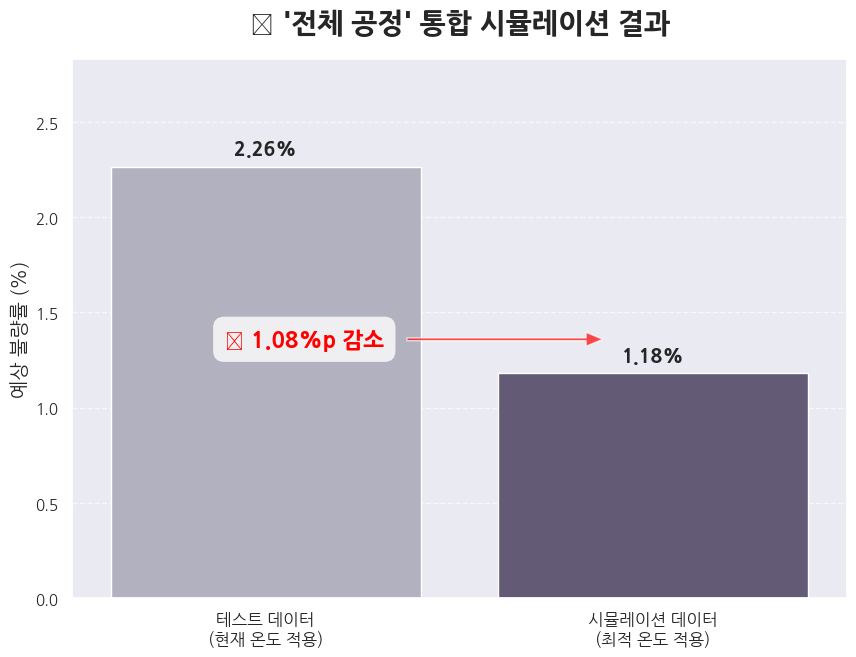



      [ 참고 ] 공정별 '개별' 온도 제어 시뮬레이션 결과 (보정됨)
     감소 개수  현재 불량률(%)  개선 후 불량률(%)
DC1    373   3.186400     0.000000
DC3    366   3.126602     0.000000
C1     347   2.972834     0.008543
C2     345   2.947207     0.000000
C4     328   2.801982     0.000000
DC2    325   2.776354     0.000000
C3     291   2.528618     0.042713

✅ 공정별 '개별' 요약 그래프 저장 완료: process_simulation_summary_individual_calibrated_split_purple.png


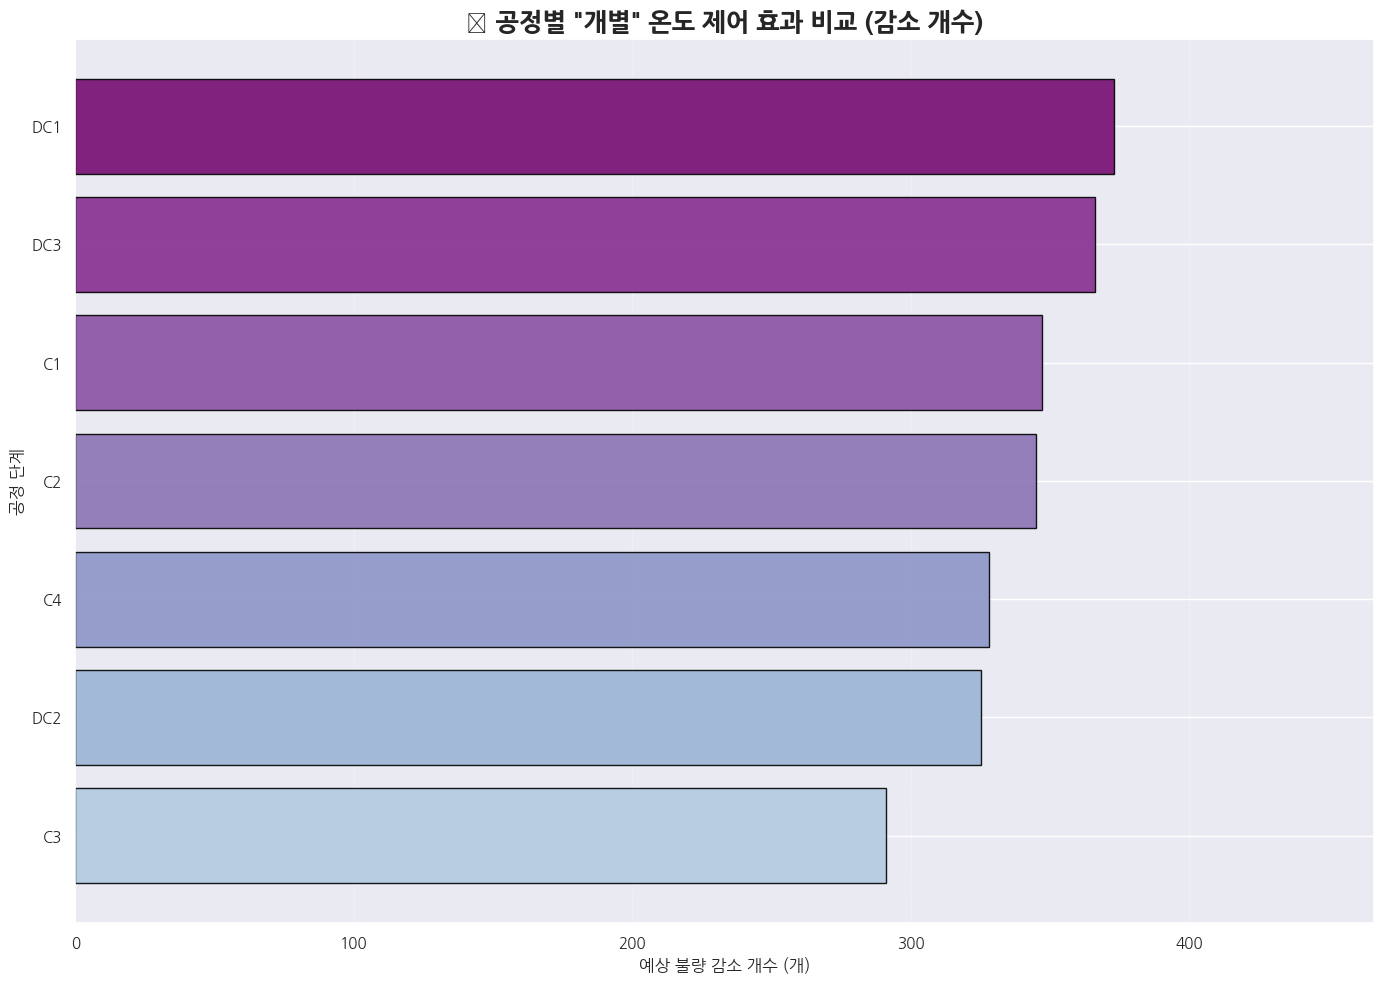

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import warnings
import traceback # 오류 추적을 위해 추가

# 경고 메시지 무시
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (환경에 맞게 수정)
try:
    plt.rc('font', family='NanumGothic')
    plt.rc('axes', unicode_minus=False) # 마이너스 부호 깨짐 방지
except:
    print("Malgun Gothic 폰트가 설치되어 있지 않습니다. 기본 폰트를 사용합니다.")


# ======================================================================
# [ 1. 사용자 설정 ]
# ======================================================================

FILE_PATH = 'final_cell_level_dataset.csv' 
TARGET_COLUMN = 'judge_encoded' 

OPTIMAL_TEMP_RANGES = {
    'c1_temp_avg': (265.5, 302.5),   
    'dc1_temp_avg': (265.0, 302.0),   
    'c2_temp_avg': (267.0, 304.0),   
    'dc2_temp_avg': (264.5, 301.5),  
    'c3_temp_avg': (262.0, 298.5),   
    'dc3_temp_avg': (262.0, 298.5),   
    'c4_temp_avg': (262.0, 298.5)    
}

OPTIMAL_TEMP_TARGETS = {
    key: (value[0] + value[1]) / 2 
    for key, value in OPTIMAL_TEMP_RANGES.items()
}

print("--- [시뮬레이션 설정] 공정별 최적 온도 (범위의 중간값) ---")
for key, value in OPTIMAL_TEMP_TARGETS.items():
    print(f"  ✅ {key}: {value / 10:.1f}°C") 
print("-------------------------------------------------")

# (4-1, 4-2, 4-3 섹션은 원본과 동일)
metrics_to_keep = [
    'c1_temp_avg', 'dc1_temp_avg', 'c2_temp_avg', 'dc2_temp_avg', 'c3_temp_avg', 'dc3_temp_avg', 'c4_temp_avg', 
    'c1_capa', 'dc1_capa', 'c2_capa', 'dc2_capa', 'c3_capa', 'dc3_capa', 'c4_capa',
    'c1_curr_end', 'dc1_curr_end', 'c2_curr_end', 'dc2_curr_end', 'c3_curr_end', 'dc3_curr_end', 'c4_curr_end', 
    'c1_ccval', 'c2_ccval', 'c3_ccval', 'c4_ccval', 'c3_cvval', 'c4_cvval',
    'c1_voltage_avg', 'dc1_voltage_avg', 'c2_voltage_avg', 'dc2_voltage_avg', 'c3_voltage_avg', 'dc3_voltage_avg', 'c4_voltage_avg', 
    'c1_time_cc', 'c2_time_cc', 'c3_time_cc', 'c4_time_cc', 'c3_time_cv', 'c4_time_cv',
    'dc1_capafit', 'dc2_capafit', 'dc3_capafit', 
    'pg1_impfit', 'pg1_imp', 'pc1_imp', 
    'pg1_voltage_start', 'pc1_voltage_start',
    'ocv1_ocv', 'oCV2_ocv', 'socv1_ocv', 'socv2_ocv', 'socv3_ocv', 'oCV2_deltaocv', 'ocv1_deltaocv',
    'm1_thick', 'm1_voltage', 'm1_res_ac', 'm1_mv', 'm1_voltage_an',
    'rta1_cell_no' 
]
LEAKAGE_KEYWORDS = ['_capa', '_capafit', '_imp', 'res_ac', '_ocv']
STAGES = ['c1', 'dc1', 'c2', 'dc2', 'c3', 'dc3', 'c4']
process_features_config = {}
print("--- [시뮬레이션 설정] 공정별 변수 자동 구성 ---")
for stage in STAGES:
    stage_name = stage.upper()
    temp_col_name = f"{stage}_temp_avg"
    stage_vars = [col for col in metrics_to_keep if col.startswith(stage + '_')]
    filtered_vars = []
    for var in stage_vars:
        is_leakage = False
        for keyword in LEAKAGE_KEYWORDS:
            if keyword in var:
                is_leakage = True
                break
        if not is_leakage:
            filtered_vars.append(var)
    if temp_col_name not in filtered_vars:
        print(f"[경고] {stage_name}의 온도 변수 '{temp_col_name}'가 없습니다.")
    elif not filtered_vars:
        print(f"[경고] {stage_name}에 사용할 수 있는 (누수 제외) 변수가 없습니다.")
    else:
        process_features_config[stage_name] = {
            'vars': filtered_vars,
            'temp_col': temp_col_name
        }
        print(f"  ✅ {stage_name} 모델: {len(filtered_vars)}개 변수 사용 (제어 변수: {temp_col_name})")
print("-------------------------------------------------")


# ======================================================================
# [ 2. 데이터 로드 및 전처리 ]
# ======================================================================
try:
    data = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"[오류] 파일을 찾을 수 없습니다: {FILE_PATH}")
    exit()
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    exit()

all_required_cols = set([TARGET_COLUMN])
for config in process_features_config.values():
    all_required_cols.update(config['vars'])

original_rows = len(data)
data = data[list(all_required_cols)].dropna()
print(f"데이터 로드 완료. (원본 {original_rows}개 행 -> NaN 제거 후 {len(data)}개 행 사용)")
print(f"전체 데이터 실제 불량률: {data[TARGET_COLUMN].mean() * 100 :.2f} %")


# ======================================================================
# [ 3. (요청) 공정별 '개별' 모델 훈련 및 시뮬레이션 루프 ]
# ======================================================================

simulation_summary = {} # 개별 공정 시뮬레이션 결과 저장

try:
    y = data[TARGET_COLUMN]
except KeyError:
    print(f"[치명적 오류] 타겟 컬럼 '{TARGET_COLUMN}'을(를) 데이터에서 찾을 수 없습니다.")
    exit()

# [개별 공정 루프]
for process_name, config in process_features_config.items():
    
    print("\n" + "="*60)
    print(f"      [ {process_name} (개별) 공정 ] 모델 훈련 및 시뮬레이션")
    print("="*60)

    try:
        # 1. X, y 데이터 선택
        feature_vars = config['vars']
        temp_col_name = config['temp_col']
        X = data[feature_vars]

        # 2. [복원] 데이터 분리 (Train/Test)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # 3. 모델 훈련
        print(f"[{process_name}] 모델 훈련 중... (Train: {len(X_train)}개, Test: {len(X_test)}개)")
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        
        model = CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6,
            scale_pos_weight=scale_pos_weight,
            random_seed=42, verbose=0, allow_writing_files=False
        )
        model.fit(X_train, y_train)

        # 4. '보정 임계값' 계산 (Train 데이터 기준)
        prob_train_original = model.predict_proba(X_train)[:, 1]
        target_defect_rate = y_train.mean() 
        threshold_calibrated = np.percentile(prob_train_original, 100 * (1 - target_defect_rate))
        
        print(f"[{process_name}] '보정 임계값' 계산 완료: {threshold_calibrated:.4f} (이 값 이상을 '불량'으로 판단)")

        # 4-2. 목표 온도 가져오기
        current_optimal_temp = OPTIMAL_TEMP_TARGETS.get(temp_col_name)
        if current_optimal_temp is None:
            print(f"[경고] {process_name} ({temp_col_name})의 최적 온도가 없습니다. 건너뜁니다.")
            continue
            
        print(f"[{process_name}] 시뮬레이션 실행 중... (제어 변수: {temp_col_name} -> {current_optimal_temp:.2f}°C)")
        
        # 4-3. (원본) 현재 조건 예측 (Test 데이터에 임계값 적용)
        prob_original = model.predict_proba(X_test)[:, 1]
        pred_original = (prob_original >= threshold_calibrated).astype(int)
        defect_count_original = np.sum(pred_original)
        defect_rate_original = defect_count_original / len(X_test) * 100

        # 4-4. (시뮬레이션) 온도 강제 제어
        X_test_simulated = X_test.copy()
        X_test_simulated[temp_col_name] = current_optimal_temp
        
        # 4-5. (개선 후) 예측 (Test 데이터에 임계값 적용)
        prob_simulated = model.predict_proba(X_test_simulated)[:, 1]
        pred_simulated = (prob_simulated >= threshold_calibrated).astype(int)
        defect_count_simulated = np.sum(pred_simulated)
        defect_rate_simulated = defect_count_simulated / len(X_test) * 100

        # 5. 결과 요약 및 저장
        reduction_count = defect_count_original - defect_count_simulated
        reduction_rate = defect_rate_original - defect_rate_simulated

        print(f"\n--- {process_name} (개별) 모델 시뮬레이션 결과 (보정됨) ---")
        print(f"  실제 불량 개수 (Test Set): {np.sum(y_test)} 개 ({y_test.mean() * 100 :.4f} %)")
        print(f"  --------------------------------------------------")
        print(f"  현재 예상 불량 셀 수: {defect_count_original} 개 ({defect_rate_original:.4f} %)")
        print(f"  개선 후 예상 불량 셀 수: {defect_count_simulated} 개 ({defect_rate_simulated:.4f} %)")
        print(f"  🔥 감소 효과: {reduction_count} 개 (불량률 {reduction_rate:.4f} %p 감소)")
        
        simulation_summary[process_name] = {
            '감소 개수': reduction_count,
            '현재 불량률(%)': defect_rate_original,
            '개선 후 불량률(%)': defect_rate_simulated
        }

    except KeyError as e:
        print(f"\n[치명적 오류] {process_name} 공정 처리 중 컬럼명 오류 발생: {e}")
    except Exception as e:
        print(f"\n[오류] {process_name} 공정 처리 중 알 수 없는 오류 발생: {e}")
        traceback.print_exc()


# ======================================================================
# [ 4. '전체 공정' 통합 시뮬레이션 (참고용) ]
# ======================================================================
print("\n\n" + "="*80)
print("      [ '전체 공정' 통합 ] 1단계: 전체 변수 모델 훈련")
print("="*80)

# try 블록 밖에서도 결과 변수를 사용할 수 있도록 None으로 초기화
reduction_rate_full = None 
defect_rate_original_full = None
defect_rate_simulated_full = None

try:
    # 1. '전체' X, y 데이터 선택
    all_feature_vars_full_model = list(all_required_cols - {TARGET_COLUMN}) # 변수명 충돌 방지
    X_full = data[all_feature_vars_full_model]

    # 2. '전체' 데이터 분리 (Train/Test)
    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
        X_full, y, test_size=0.3, random_state=42, stratify=y 
    )
    
    # 3. '전체' 모델 훈련
    print(f"[전체 모델] 훈련 중... (Train: {len(X_train_full)}개, Test: {len(X_test_full)}개)")
    scale_pos_weight_full = (y_train_full == 0).sum() / (y_train_full == 1).sum()
    
    full_model = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        scale_pos_weight=scale_pos_weight_full,
        random_seed=42, verbose=0, allow_writing_files=False
    )
    full_model.fit(X_train_full, y_train_full)

    # 4. '보정 임계값' 계산 (Train 데이터 기준)
    prob_train_full_original = full_model.predict_proba(X_train_full)[:, 1]
    target_defect_rate_full = y_train_full.mean()
    threshold_calibrated_full = np.percentile(prob_train_full_original, 100 * (1 - target_defect_rate_full))
    
    print(f"[전체 모델] '보정 임계값' 계산 완료: {threshold_calibrated_full:.4f} (이 값 이상을 '불량'으로 판단)")
    print(f"[전체 모델] 시뮬레이션 실행 중... (7개 공정 온도 동시 제어)")
    
    # 4-2. (원본) 현재 조건 예측 (Test 데이터에 임계값 적용)
    prob_original_full = full_model.predict_proba(X_test_full)[:, 1]
    pred_original_full = (prob_original_full >= threshold_calibrated_full).astype(int)
    defect_count_original_full = np.sum(pred_original_full)
    defect_rate_original_full = defect_count_original_full / len(X_test_full) * 100

    # 4-3. (시뮬레이션) '모든' 공정 온도 강제 제어
    X_test_simulated_full = X_test_full.copy()
    temp_cols_updated = 0
    for temp_col, optimal_val in OPTIMAL_TEMP_TARGETS.items():
        if temp_col in X_test_simulated_full.columns:
            X_test_simulated_full[temp_col] = optimal_val
            temp_cols_updated += 1
    
    print(f"  -> {temp_cols_updated}개 공정의 온도를 최적 값으로 동시 변경 완료.")

    # 4-4. (개선 후) 예측 (Test 데이터에 임계값 적용)
    prob_simulated_full = full_model.predict_proba(X_test_simulated_full)[:, 1]
    pred_simulated_full = (prob_simulated_full >= threshold_calibrated_full).astype(int)
    defect_count_simulated_full = np.sum(pred_simulated_full)
    defect_rate_simulated_full = defect_count_simulated_full / len(X_test_full) * 100

    # 5. '전체' 결과 요약
    reduction_count_full = defect_count_original_full - defect_count_simulated_full
    reduction_rate_full = defect_rate_original_full - defect_rate_simulated_full # 0.0000%p 버그 수정

    print("\n" + "="*80)
    print(f"      [ 🔥 '전체 공정' 통합 시뮬레이션 최종 결과 (보정됨) 🔥 ]")
    print("="*80)
    print(f"  (Test Set 실제 불량률: {y_test_full.mean() * 100 :.4f} %)")
    print(f"  --------------------------------------------------")
    print(f"  현재 예상 불량 셀 수 (A): {defect_count_original_full} 개 ({defect_rate_original_full:.4f} %)")
    print(f"  모든 공정 개선 후 예상 불량 셀 수 (B): {defect_count_simulated_full} 개 ({defect_rate_simulated_full:.4f} %)")
    print(f"  --------------------------------------------------")
    print(f"  🔥🔥🔥 최종 감소 효과 (A-B): {reduction_count_full} 개")
    print(f"  🔥🔥🔥 최종 불량률 개선: {reduction_rate_full:.4f} %p 감소")
    print("="*80)

except Exception as e:
    print(f"\n[오류] '전체 공정' 통합 시뮬레이션 중 오류 발생: {e}")
    traceback.print_exc()

# ======================================================================
# [ 4-B. (신규) '전체 공정' 결과 시각화 (Before/After) ]
# ======================================================================

# [ 4. ] 블록에서 계산된 변수(reduction_rate_full 등)가 있어야 함
if reduction_rate_full is not None:
    print("\n\n" + "="*80)
    print("      [ '전체 공정' 통합 시뮬레이션 시각화 ]")
    print("="*80)

    try:
        # 1. 데이터 준비
        labels = ['테스트 데이터\n(현재 온도 적용)', '시뮬레이션 데이터\n(최적 온도 적용)']
        values = [defect_rate_original_full, defect_rate_simulated_full]
        
        plt.figure(figsize=(10, 7)) 
        # [색상 수정] palette를 '보라색 계열' 2가지로 지정
        bars = sns.barplot(x=labels, y=values, palette=['#B0AEC3', '#61567A']) 
        
        # 2. 텍스트 레이블 추가
        for i, v in enumerate(values):
            plt.text(i, v + (max(values) * 0.02), 
                     f'{v:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')
            
        # 3. 화살표 및 감소 효과 텍스트 추가
        y_pos = max(values) * 0.6 
        x_start = 0.1
        x_end = 0.9
        
        plt.annotate(f'🔥 {reduction_rate_full:.2f}%p 감소',
                     xy=(x_end, y_pos),
                     xytext=(x_start, y_pos),
                     arrowprops=dict(facecolor='red', shrink=0.05, alpha=0.7, width=2, headwidth=10),
                     ha='center', va='center', fontsize=16, fontweight='bold', color='red',
                     bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='none', alpha=0.8))

        # 4. 차트 꾸미기
        plt.title('🔥 \'전체 공정\' 통합 시뮬레이션 결과', fontsize=20, fontweight='bold', pad=20)
        plt.ylabel('예상 불량률 (%)', fontsize=14)
        plt.xlabel('')
        plt.ylim(0, max(values) * 1.25) 
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(fontsize=12)
        
        plt.savefig('total_simulation_result_calibrated.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("✅ '전체 공정' 시뮬레이션 결과 그래프 저장 완료: total_simulation_result_calibrated.png")
        plt.show()

    except Exception as e:
        print(f"\n[오류] '전체 공정' 시각화 중 오류 발생: {e}")
        traceback.print_exc()
else:
    print("\n[알림] '전체 공정' 시뮬레이션이 성공적으로 실행되지 않아 시각화를 건너뜁니다.")


# ======================================================================
# [ 5. (요청) '개별 공정' 최종 결과 요약 및 시각화 ]
# ======================================================================

if simulation_summary:
    print("\n\n" + "="*80)
    print("      [ 참고 ] 공정별 '개별' 온도 제어 시뮬레이션 결과 (보정됨)")
    print("="*80)
    
    df_summary = pd.DataFrame.from_dict(simulation_summary, orient='index')
    df_summary = df_summary.sort_values(by='감소 개수', ascending=False)
    
    print(df_summary)
    
    # [수정] 그래프가 뭉개지지 않도록 figsize 높이 조절
    plt.figure(figsize=(14, 10)) 
    df_summary_sorted = df_summary.sort_values(by='감소 개수', ascending=True)
    
    # [색상 수정] '보라색 계열' 팔레트 적용
    colors_gradient = plt.cm.BuPu(np.linspace(0.3, 0.9, len(df_summary_sorted)))
    bars = plt.barh(df_summary_sorted.index, df_summary_sorted['감소 개수'], color=colors_gradient , alpha=0.9, edgecolor='black')
    
    plt.title(f'🔥 공정별 "개별" 온도 제어 효과 비교 (감소 개수)', fontsize=18, fontweight='bold')
    plt.xlabel('예상 불량 감소 개수 (개)', fontsize=12)
    plt.ylabel('공정 단계', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    max_val = df_summary['감소 개수'].max()
    min_val = df_summary['감소 개수'].min()

    for bar in bars:
        # --- [오류 수정] KeyError: '_nolegend_' 방지 ---
        label = bar.get_label()
        if label.startswith('_'):
            continue
        # -------------------------------------------
            
        width = bar.get_width()
        
        # (모델 이름은 이 시나리오에서는 저장하지 않았으므로 제거)
        
        if width < 0:
            # [오류 수정] max_val이 0일 경우 대비
            label_x_pos = width - (max_val * 0.02) if max_val > 0 else width - 0.1
            ha = 'right'
            color = 'red' 
            text = f"{width} 개 (악화)"
        else:
            # [오류 수정] max_val이 0일 경우 대비
            label_x_pos = width + (max_val * 0.02) if max_val > 0 else width + 0.1
            ha = 'left'
            color = "#61567A" # 텍스트는 지정한 보라색
            text = f"+{width} 개 감소"
            
        plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, text, 
                 va='center', ha=ha, fontsize=10, fontweight='bold', color=color )

    # --- [오류 수정] xlim 버그 수정 ---
    x_start = 0
    if min_val < 0:
        x_start = min_val * 1.15
        
    x_end = max_val * 1.25 # 텍스트가 잘리지 않게 넉넉하게
    
    max_abs_val = max(abs(min_val), abs(max_val))
    if max_abs_val > 0:
        plt.xlim(x_start, x_end) 
    else:
        plt.xlim(-1, 1) # 기본값
    # ---------------------------------

    plt.tight_layout()
    plt.savefig('process_simulation_summary_individual_calibrated_split_purple.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("\n✅ 공정별 '개별' 요약 그래프 저장 완료: process_simulation_summary_individual_calibrated_split_purple.png")
    plt.show()

else:
    print("\n[알림] '개별' 시뮬레이션이 정상적으로 실행되지 않아 요약할 결과가 없습니다.")

데이터 로드 완료: final_cell_level_dataset.csv

--- [시각화 1] '온도 구간별 불량률' 차트 생성 중... ---
✅ 'ppt_chart_1_defect_by_temp_bin.png' 저장 완료.


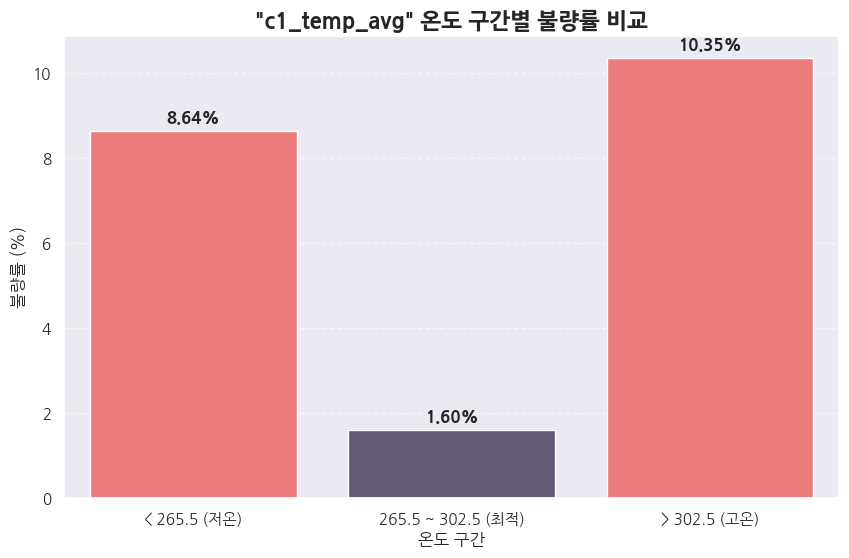


--- [시각화 2] '단계별 최적 온도 범위' 차트 생성 중... ---
✅ 'ppt_chart_2_optimal_temp_ranges.png' 저장 완료.


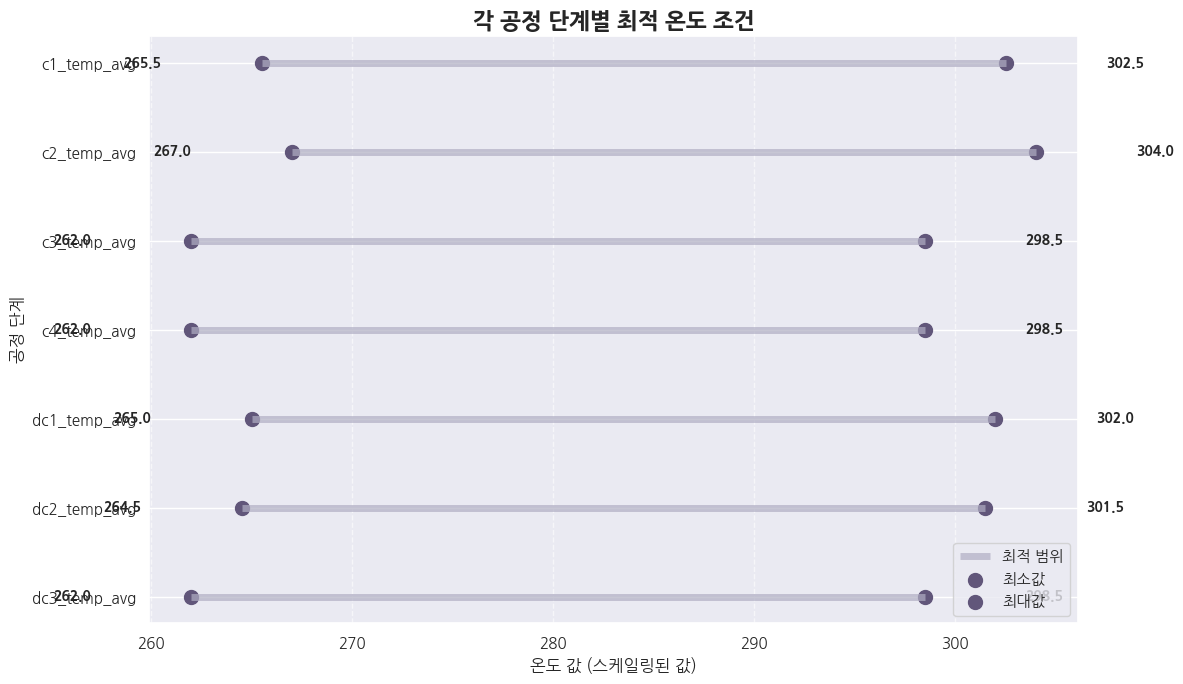

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- 설정 ---
warnings.filterwarnings('ignore')
try:
    plt.rc('font', family='NanumGothic')
    plt.rc('axes', unicode_minus=False)
except:
    print("한글 폰트(NanumGothic)가 없습니다. 기본 폰트를 사용합니다.")

FILE_PATH = 'final_cell_level_dataset.csv' 
TARGET_COLUMN = 'judge_encoded' 

# [ 1. 사용자 설정 ]
# battery_simulation_workflow.py와 동일한 설정값을 사용합니다.
OPTIMAL_TEMP_RANGES = {
    'c1_temp_avg': (265.5, 302.5),   
    'dc1_temp_avg': (265.0, 302.0),   
    'c2_temp_avg': (267.0, 304.0),   
    'dc2_temp_avg': (264.5, 301.5),  
    'c3_temp_avg': (262.0, 298.5),   
    'dc3_temp_avg': (262.0, 298.5),   
    'c4_temp_avg': (262.0, 298.5)    
}

# --- 데이터 로드 ---
try:
    data = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"[오류] 파일을 찾을 수 없습니다: {FILE_PATH}")
    exit()
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    exit()

print(f"데이터 로드 완료: {FILE_PATH}")

# ======================================================================
# [ 시각화 1 ] 온도 구간별 불량률 비교 (PPT의 "온도 구간별 불량률 비교")
# ======================================================================
# (C1 공정을 예시로 생성합니다)

print("\n--- [시각화 1] '온도 구간별 불량률' 차트 생성 중... ---")
try:
    target_stage = 'c1_temp_avg'
    min_val, max_val = OPTIMAL_TEMP_RANGES[target_stage]

    # 1. 3개의 온도 구간(Bin)으로 데이터를 나눕니다.
    bins = [-np.inf, min_val, max_val, np.inf]
    labels = [f'< {min_val} (저온)', f'{min_val} ~ {max_val} (최적)', f'> {max_val} (고온)']
    
    data['temp_bin'] = pd.cut(data[target_stage], bins=bins, labels=labels, right=False)

    # 2. 각 구간(Bin)별로 불량률(TARGET_COLUMN의 평균)을 계산합니다.
    df_bin_defect = data.groupby('temp_bin')[TARGET_COLUMN].mean().reset_index()
    df_bin_defect[TARGET_COLUMN] = df_bin_defect[TARGET_COLUMN] * 100 # 백분율로 변환

    # 3. 막대그래프로 시각화
    plt.figure(figsize=(10, 6))
    bars = sns.barplot(x='temp_bin', y=TARGET_COLUMN, data=df_bin_defect, palette=['#FF6B6B', '#61567A', '#FF6B6B'])
    
    plt.title(f'"{target_stage}" 온도 구간별 불량률 비교', fontsize=16, fontweight='bold')
    plt.xlabel('온도 구간', fontsize=12)
    plt.ylabel('불량률 (%)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars.patches:
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.2f}%',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.savefig('ppt_chart_1_defect_by_temp_bin.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✅ 'ppt_chart_1_defect_by_temp_bin.png' 저장 완료.")
    plt.show()

except Exception as e:
    print(f"[오류] 시각화 1 생성 중 오류: {e}")

# ======================================================================
# [ 시각화 2 ] 각 단계별 최적 온도 조건 (PPT의 "각 단계별 최적 온도 조건")
# ======================================================================
# (Dumbbell Plot으로 최적 범위를 시각화합니다)

print("\n--- [시각화 2] '단계별 최적 온도 범위' 차트 생성 중... ---")
try:
    # 1. 딕셔너리를 DataFrame으로 변환
    df_ranges = pd.DataFrame.from_dict(OPTIMAL_TEMP_RANGES, orient='index', columns=['Min', 'Max'])
    df_ranges = df_ranges.sort_index(ascending=False) # C4 -> C1 순서로
    
    plt.figure(figsize=(12, 7))
    
    # 2. Dumbbell Plot (덤벨 플롯) 생성
    #    (min과 max 사이에 수평선(hlines)을 그립니다)
    plt.hlines(y=df_ranges.index, xmin=df_ranges['Min'], xmax=df_ranges['Max'], 
               color='#B0AEC3', alpha=0.7, linewidth=5, label='최적 범위')
    
    # 3. 최소/최대값에 점 찍기
    plt.scatter(df_ranges['Min'], df_ranges.index, color='#61567A', s=100, label='최소값')
    plt.scatter(df_ranges['Max'], df_ranges.index, color='#61567A', s=100, label='최대값')

    # 4. 텍스트 레이블 추가
    for i, row in df_ranges.iterrows():
        plt.text(row['Min'] - 5, i, f'{row["Min"]:.1f}', ha='right', va='center', fontsize=10, fontweight='bold')
        plt.text(row['Max'] + 5, i, f'{row["Max"]:.1f}', ha='left', va='center', fontsize=10, fontweight='bold')

    # 5. 차트 꾸미기
    plt.title('각 공정 단계별 최적 온도 조건', fontsize=16, fontweight='bold')
    plt.xlabel('온도 값 (스케일링된 값)', fontsize=12)
    plt.ylabel('공정 단계', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    plt.savefig('ppt_chart_2_optimal_temp_ranges.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✅ 'ppt_chart_2_optimal_temp_ranges.png' 저장 완료.")
    plt.show()

except Exception as e:
    print(f"[오류] 시각화 2 생성 중 오류: {e}")

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def create_ewma_chart(data_series, variable_name, lambda_val=0.2, L=3):
    """
    주어진 데이터 시리즈(Series)에 대해 EWMA 관리도를 생성합니다.
    
    :param data_series: (pd.Series) 모니터링할 시계열 데이터
    :param variable_name: (str) 차트 제목에 사용할 변수 이름
    :param lambda_val: (float) EWMA 가중치 (0~1). 낮을수록 과거 데이터를 많이 반영.
    :param L: (float) 시그마 승수 (예: 3-sigma 관리도)
    """
    
    print(f"\n--- {variable_name} EWMA 관리도 생성 중 ---")
    
    # 1. EWMA 통계량 계산
    # pd.Series.ewm()을 사용하면 EWMA 값을 쉽게 계산할 수 있습니다.
    # adjust=True (기본값)는 초반 데이터의 가중치를 조정합니다.
    ewma_values = data_series.ewm(span=(2/lambda_val) - 1, adjust=True).mean()
    
    # 2. 중심선(CL) 및 표준편차 계산
    # (안정된 공정을 가정하고 전체 데이터의 평균/표준편차 사용)
    CL = data_series.mean()
    sigma = data_series.std()
    
    # 3. 관리 상한(UCL) 및 하한(LCL) 계산
    # EWMA 관리도의 한계선은 초반에 더 좁았다가 점차 안정화됩니다.
    n_points = len(data_series)
    t = np.arange(1, n_points + 1)
    
    # 변동폭 계수
    factor = L * sigma * np.sqrt( (lambda_val / (2 - lambda_val)) * (1 - (1 - lambda_val)**(2 * t)) )
    
    UCL = CL + factor
    LCL = CL - factor
    
    # 4. 관리 이탈 지점 확인
    out_of_control = (ewma_values > UCL) | (ewma_values < LCL)
    
    # 5. 시각화 (Matplotlib)
    plt.figure(figsize=(15, 7))
    
    # 5-1. 원본 데이터 (참고용)
    plt.plot(data_series.index, data_series.values, color='gray', alpha=0.3, label=f'원본 {variable_name}')
    
    # 5-2. EWMA 값 (핵심)
    plt.plot(ewma_values.index, ewma_values, color='blue', label=f'EWMA ($\lambda$={lambda_val})')
    
    # 5-3. 관리 한계선
    plt.plot(ewma_values.index, UCL, color='red', linestyle='--', label=f'UCL (L={L})')
    plt.plot(ewma_values.index, LCL, color='red', linestyle='--', label=f'LCL (L={L})')
    plt.axhline(CL, color='black', linestyle='-', label='Center Line (CL)')
    
    # 5-4. 이탈 지점 강조
    if out_of_control.any():
        plt.scatter(data_series.index[out_of_control], ewma_values[out_of_control], 
                    marker='o', s=100, facecolors='none', edgecolors='red', lw=2,
                    label='관리 이탈 (Out of Control)')
    
    plt.title(f'{variable_name} EWMA 관리도 (공정 추세 모니터링)', fontsize=16)
    plt.xlabel('데이터 순서 (시간)')
    plt.ylabel('EWMA 값')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # 파일로 저장
    output_filename = f'ewma_chart_{variable_name}.png'
    plt.savefig(output_filename)
    plt.close()
    
    print(f"-> '{output_filename}' 파일에 EWMA 관리도 저장 완료.")
    print(f"  (관리 이탈 지점 {out_of_control.sum()}개 발견)")

# ======================================================================
# [최종 실행 부분]
# ======================================================================
try:
    # 1. 데이터 로드
    df_process = pd.read_csv('bat_process.csv', encoding='cp949')
    
    # 2. 모니터링할 변수 선택
    # (주의: EWMA는 시간 순서가 중요하므로, 날짜/시간으로 정렬해야 하나
    #       여기서는 'dt_start'를 정렬하여 순서를 만듭니다.)
    
    # 날짜/시간 변환
    df_process['dt_start'] = pd.to_datetime(df_process['dt_start'], format='%d%b%y:%H:%M:%S')
    
    # 시간순으로 정렬
    df_process = df_process.sort_values(by='dt_start').reset_index(drop=True)
    
    # 3. 결측치 처리 (NaN 값 삭제)
    # C4 온도 데이터
    c4_temp_data = df_process['c4_temp_avg'].dropna()
    
    # (참고) pg1_imp (임피던스) 데이터
    # pg1_imp_data = df_process['pg1_imp'].dropna()

    # 4. EWMA 차트 생성 실행
    if not c4_temp_data.empty:
        create_ewma_chart(c4_temp_data, 'c4_temp_avg')
    else:
        print("오류: 'c4_temp_avg' 데이터가 비어있거나 모두 NaN입니다.")
        
    # (임피던스 차트도 필요시 주석 해제)
    # if not pg1_imp_data.empty:
    #    create_ewma_chart(pg1_imp_data, 'pg1_imp', lambda_val=0.15)

except FileNotFoundError:
    print(f"[오류] 'bat_process.csv' 파일을 찾을 수 없습니다.")
except Exception as e:
    print(f"\n[치명적 오류] 실행 중 문제 발생: {e}")
    traceback.print_exc()


--- c4_temp_avg EWMA 관리도 생성 중 ---
-> 'ewma_chart_c4_temp_avg.png' 파일에 EWMA 관리도 저장 완료.
  (관리 이탈 지점 11609개 발견)


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback

def create_tray_ewma_chart(file_path, variable_name='c4_temp_avg_mean', lambda_val=0.2, L=3):
    """
    트레이별 평균 데이터(c4_temp_avg_mean)에 대한 EWMA 관리도를 생성합니다.
    """
    
    try:
        # 1. 데이터 로드 (트레이 레벨 데이터)
        df = pd.read_csv(file_path)
        
        # 2. lot_id와 tray_id를 기준으로 정렬하여 시간 순서를 확립
        if 'lot_id' in df.columns:
            df = df.sort_values(by=['lot_id', 'tray_id']).reset_index(drop=True)
        else:
            df = df.sort_values(by='tray_id').reset_index(drop=True)

        # 3. 모니터링할 데이터 추출 및 NaN 확인
        if variable_name not in df.columns:
            print(f"[오류] 컬럼 '{variable_name}'가 데이터셋에 없습니다.")
            return

        data_series = df[variable_name].dropna()
        
        if data_series.empty:
            print(f"[오류] '{variable_name}' 데이터가 비어있습니다.")
            return

        print(f"\n--- 트레이별 {variable_name} EWMA 관리도 계산 시작 ---")

        # 4. EWMA 통계량 및 관리 한계선 계산
        ewma_values = data_series.ewm(span=(2/lambda_val) - 1, adjust=True).mean()
        CL = data_series.mean()
        sigma = data_series.std()
        
        n_points = len(data_series)
        t = np.arange(1, n_points + 1)
        factor = L * sigma * np.sqrt( (lambda_val / (2 - lambda_val)) * (1 - (1 - lambda_val)**(2 * t)) )
        
        UCL = CL + factor
        LCL = CL - factor
        
        # 5. 관리 이탈 지점 확인
        out_of_control = (ewma_values > UCL) | (ewma_values < LCL)
        
        # 6. 시각화 (Matplotlib)
        plt.figure(figsize=(18, 8))
        x_index = data_series.index
        
        plt.plot(x_index, data_series.values, color='gray', alpha=0.3, linestyle='None', marker='.', markersize=4, label=f'트레이별 평균 ({variable_name})')
        plt.plot(x_index, ewma_values, color='blue', linewidth=2, label=f'EWMA ($\lambda$={lambda_val})')
        
        # 관리 한계선
        plt.plot(x_index, UCL, color='red', linestyle='--', label=f'UCL (L={L})')
        plt.plot(x_index, LCL, color='red', linestyle='--', label=f'LCL (L={L})')
        plt.axhline(CL, color='black', linestyle='-', label='Center Line (CL)')
        
        # 이탈 지점 강조
        if out_of_control.any():
            plt.scatter(x_index[out_of_control], ewma_values[out_of_control], 
                        marker='o', s=120, facecolors='none', edgecolors='red', lw=2,
                        label=f'관리 이탈 ({out_of_control.sum()}개)')
        
        plt.title(f'트레이별 평균 온도 ({variable_name}) EWMA 관리도', fontsize=18)
        plt.xlabel('트레이 순서 (Lot 및 Tray ID 기준 정렬)')
        plt.ylabel('EWMA 값 (온도)')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        
        output_filename = f'ewma_chart_{variable_name}_tray_level.png'
        plt.savefig(output_filename)
        plt.close()
        
        print(f"\n✅ EWMA 관리도 저장 완료: {output_filename}")
        print(f"  총 트레이 수: {n_points}")
        print(f"  관리 이탈 트레이 수: {out_of_control.sum()}개")

    except Exception as e:
        print(f"\n[치명적 오류] 실행 중 문제 발생: {e}")
        traceback.print_exc()


# --- 최종 실행 지시 ---
# [주의: 이전에 생성한 트레이별 데이터 파일명으로 수정해야 합니다.]
create_tray_ewma_chart('final_tray_level_dataset_C4_only.csv')


--- 트레이별 c4_temp_avg_mean EWMA 관리도 계산 시작 ---

✅ EWMA 관리도 저장 완료: ewma_chart_c4_temp_avg_mean_tray_level.png
  총 트레이 수: 1797
  관리 이탈 트레이 수: 110개


In [38]:
import pandas as pd
import numpy as np
import traceback 

def create_tray_level_data_with_time():
    """ 원본 셀 데이터를 트레이 레벨로 집계하고 최종 CSV 파일을 생성합니다. (시간 변수 추가) """
    try:
        print("="*50)
        print("      [PART 1: C4 전용 데이터 생성 및 시간 변수 추가 시작]")
        print("="*50)
        
        # --- 파일 로드 ---
        df_process = pd.read_csv('bat_process.csv', encoding='cp949')
        df_tat = pd.read_csv('bat_tat.csv', encoding='utf-8')

        # 데이터 정리 및 시간 변수 변환 [!!! 수정됨 !!!]
        df_process.replace(r'^\s*$', np.nan, regex=True, inplace=True)
        # dt_start를 숫자로 변환 (UNIX Time)하여 평균을 구할 수 있게 합니다.
        df_process['dt_start_numeric'] = pd.to_datetime(df_process['dt_start'], format='%d%b%y:%H:%M:%S').apply(lambda x: x.timestamp())
        
        df_process['judge_encoded'] = (df_process['judge'] == '불량').astype(int)
        
        # --- 3. 집계(Aggregation) 정의 ---
        metrics_to_agg = [
            'c4_temp_avg', 'c4_capa', 'c4_voltage_avg', 'c4_curr_end', 
            'c4_time_cc', 'c4_time_cv',
        ]
        
        agg_dict = {'judge_encoded': ['mean', 'count', 'sum']}
        for col in metrics_to_agg:
            if col in df_process.columns:
                agg_dict[col] = ['mean', 'std']
        
        # [!!! CRITICAL CHANGE !!!] 시간 변수 추가
        agg_dict['dt_start_numeric'] = ['mean']

        df_tray_agg = df_process.groupby('tray_id').agg(agg_dict)
        
        # 컬럼 정리
        df_tray_agg.columns = [f"{col[0]}_{col[1]}" for col in df_tray_agg.columns]
        df_tray_agg = df_tray_agg.rename(columns={
            'judge_encoded_mean': 'defect_rate', 
            'judge_encoded_count': 'cell_count', 
            'judge_encoded_sum': 'defect_count',
            'dt_start_numeric_mean': 'dt_start_mean' # 새 컬럼 이름
        })
        std_cols = [col for col in df_tray_agg.columns if col.endswith('_std')]
        df_tray_agg[std_cols] = df_tray_agg[std_cols].fillna(0)
        
        # TAT 데이터와 최종 병합
        final_tray_level_df = pd.merge(df_tray_agg, df_tat, on='tray_id', how='inner')
        
        output_file = 'final_tray_level_dataset_C4_with_time.csv'
        final_tray_level_df.to_csv(output_file, index=False)
        
        print("\n[성공] 트레이별 집계 데이터 (시간 변수 포함) 생성 완료.")
        return output_file
    
    except Exception as e:
        print(f"\n[오류] 데이터 생성 중 문제 발생: {e}")
        traceback.print_exc()
        return None

# ======================================================================
# [EWMA 코드 (X축: 시간) 적용]
# ======================================================================
def create_tray_ewma_chart_by_time(file_path, variable_name='c4_temp_avg_mean', time_column='dt_start_mean', lambda_val=0.2, L=3):
    """
    트레이별 평균 데이터(c4_temp_avg_mean)를 시간순으로 정렬하여 EWMA 관리도를 생성합니다.
    """
    
    try:
        # 1. 데이터 로드 및 정렬
        df = pd.read_csv(file_path)
        
        # Unix Time을 Datetime으로 재변환 및 정렬 [!!! 핵심 변경 !!!]
        df[time_column] = pd.to_datetime(df[time_column], unit='s')
        df = df.sort_values(by=time_column).reset_index(drop=True)

        data_series = df[variable_name].dropna()
        date_series = df[time_column].iloc[data_series.index] # NaN 제거 후 인덱스 맞추기
        
        if data_series.empty:
            print(f"[오류] '{variable_name}' 데이터가 비어있습니다.")
            return

        print(f"\n--- {variable_name} EWMA 관리도 계산 시작 (X축: 실제 시간) ---")

        # 2. EWMA 통계량 및 관리 한계선 계산 (이전과 동일)
        ewma_values = data_series.ewm(span=(2/lambda_val) - 1, adjust=True).mean()
        CL = data_series.mean()
        sigma = data_series.std()
        
        n_points = len(data_series)
        t = np.arange(1, n_points + 1)
        factor = L * sigma * np.sqrt( (lambda_val / (2 - lambda_val)) * (1 - (1 - lambda_val)**(2 * t)) )
        UCL = CL + factor
        LCL = CL - factor
        
        out_of_control = (ewma_values > UCL) | (ewma_values < LCL)
        
        # 3. 시각화 (Matplotlib)
        plt.figure(figsize=(18, 8))
        
        # X축에 실제 시간(Datetime) 사용
        plt.plot(date_series, data_series.values, color='gray', alpha=0.3, linestyle='None', marker='.', markersize=4, label=f'트레이별 평균 ({variable_name})')
        plt.plot(date_series, ewma_values, color='blue', linewidth=2, label=f'EWMA ($\lambda$={lambda_val})')
        
        # 관리 한계선
        plt.plot(date_series, UCL, color='red', linestyle='--', label=f'UCL (L={L})')
        plt.plot(date_series, LCL, color='red', linestyle='--', label=f'LCL (L={L})')
        plt.axhline(CL, color='black', linestyle='-', label='Center Line (CL)')
        
        # 이탈 지점 강조
        if out_of_control.any():
            plt.scatter(date_series[out_of_control.values], ewma_values[out_of_control.values], 
                        marker='o', s=120, facecolors='none', edgecolors='red', lw=2,
                        label=f'관리 이탈 ({out_of_control.sum()}개)')
        
        plt.title(f'트레이별 평균 온도 ({variable_name}) EWMA 관리도', fontsize=18)
        plt.xlabel('시간 (dt_start_mean)')
        plt.ylabel('EWMA 값 (온도)')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        
        output_filename = f'ewma_chart_{variable_name}_actual_timeline.png'
        plt.savefig(output_filename)
        plt.close()
        
        print(f"\n✅ EWMA 관리도 저장 완료: {output_filename}")
        print(f"  총 트레이 수: {n_points}")
        print(f"  관리 이탈 트레이 수: {out_of_control.sum()}개")

    except Exception as e:
        print(f"\n[치명적 오류] 실행 중 문제 발생: {e}")
        traceback.print_exc()

# --- 최종 실행 지시 ---
if __name__ == "__main__":
    file_path = create_tray_level_data_with_time()
    if file_path:
        # C4 공정 온도 (c4_temp_avg_mean)에 대한 EWMA 관리도를 생성합니다.
        create_tray_ewma_chart_by_time(file_path)

      [PART 1: C4 전용 데이터 생성 및 시간 변수 추가 시작]

[성공] 트레이별 집계 데이터 (시간 변수 포함) 생성 완료.

--- c4_temp_avg_mean EWMA 관리도 계산 시작 (X축: 실제 시간) ---

✅ EWMA 관리도 저장 완료: ewma_chart_c4_temp_avg_mean_actual_timeline.png
  총 트레이 수: 1797
  관리 이탈 트레이 수: 154개
